# 🎮 Previsão de Vitória em League of Legends

## 📌 Sobre o Projeto

Em uma partida competitiva de **League of Legends**, pequenas vantagens acumuladas ao longo do jogo podem indicar qual equipe possui maior probabilidade de vencer. Ouro, experiência, eliminações, objetivos e outras características ajudam a representar o estado atual da partida.

Pensando nisso, este projeto busca responder à seguinte pergunta:

> **Com base nas informações acumuladas durante uma partida, é possível estimar a probabilidade de vitória da equipe Blue?**

Para responder a essa questão, foram utilizados dados históricos de partidas de League of Legends e técnicas de **Machine Learning para classificação**.

O objetivo não é apenas determinar se a equipe Blue venceu ou perdeu, mas também avaliar a capacidade dos modelos de identificar padrões presentes nas partidas e estimar suas **chances de vitória**.

## 🎯 Objetivos

- Analisar os principais fatores relacionados ao resultado das partidas;
- Explorar a relação entre as características das equipes e a vitória;
- Comparar diferentes formas de representação dos dados;
- Desenvolver modelos capazes de prever `blueWins`;
- Avaliar as probabilidades estimadas pelos modelos;
- Identificar quais características possuem maior relevância para as previsões.

## 💡 Problema de Negócio

Uma aplicação prática desse tipo de modelo poderia auxiliar em sistemas de **acompanhamento e análise de partidas**, permitindo estimar a probabilidade de vitória de uma equipe conforme novas informações são acumuladas durante o jogo.

Por exemplo, a partir das diferenças de ouro, experiência, eliminações e objetivos entre as equipes, seria possível estimar:

> **"Com o estado atual da partida, qual é a probabilidade de a equipe Blue vencer?"**

Essa informação poderia ser utilizada em ferramentas de análise esportiva, acompanhamento de partidas competitivas, estudos de desempenho e sistemas de previsão.

## 🔬 Abordagem

Foram desenvolvidas duas representações dos dados:

- **`lol_diff`** — utiliza diferenças entre as estatísticas das equipes Blue e Red;
- **`lol_no_diff`** — mantém as estatísticas de cada equipe separadamente.

As duas abordagens foram comparadas utilizando modelos de **Random Forest** e **XGBoost**, tanto em suas configurações base quanto após otimização de hiperparâmetros com validação cruzada.

Ao final, os modelos foram avaliados utilizando métricas de classificação, **ROC-AUC, matriz de confusão, calibração das probabilidades e importância das features**.

# 🔎 1 - Exploração dos dados

Nesta primeira etapa, será realizada uma análise inicial do dataset lol_ranked_win, buscando compreender sua estrutura e as informações disponíveis.

Serão verificadas a quantidade de registros e variáveis, os tipos de dados, valores ausentes, possíveis duplicidades e as principais características das colunas.

O objetivo é obter uma visão geral do conjunto de dados antes de iniciar as etapas de tratamento e análise, identificando possíveis problemas que possam influenciar os resultados do projeto.

In [1]:
# Importando principal biblioteca para carregamento do dataset

import pandas as pd

In [2]:
# Carregando o dataset e cofigurando a quantidade de colunas a serem exibidas no output do notebook
lol = pd.read_csv('data.csv')

pd.set_option('display.max_columns', None)

In [3]:
print(f'O dataset possui {lol.shape[0]} linhas e {lol.shape[1]} colunas.')

O dataset possui 9879 linhas e 40 colunas.


In [4]:
# Exibindo as 10 primeiras linhas do dataset

lol.head(10)

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,19.5,1721.0,15,6,0,6,9,8,0,0,0,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,17.4,1471.2,12,1,1,5,5,2,2,1,1,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,18.6,1611.3,15,3,1,11,7,14,0,0,0,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,20.1,1515.7,15,2,1,5,4,10,0,0,0,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,21.0,1640.0,17,2,1,6,6,7,1,1,0,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4
5,4475365709,1,18,0,0,5,3,6,1,1,0,0,15899,7.0,18161,225,42,698,101,22.5,1589.9,36,5,1,3,5,2,0,0,0,0,15201,7.0,18060,221,59,-698,-101,22.1,1520.1
6,4493010632,1,18,3,1,7,6,7,1,1,0,0,16874,6.8,16967,225,53,2411,1563,22.5,1687.4,57,1,0,6,7,9,0,0,0,0,14463,6.4,15404,164,35,-2411,-1563,16.4,1446.3
7,4496759358,0,16,2,0,5,13,3,0,0,0,0,15305,6.4,16138,209,48,-2615,-800,20.9,1530.5,15,0,1,13,5,11,1,1,0,0,17920,6.6,16938,157,54,2615,800,15.7,1792.0
8,4443048030,0,16,3,0,7,7,8,0,0,0,0,16401,7.2,18527,189,61,-1979,-771,18.9,1640.1,15,2,1,7,7,5,2,1,1,0,18380,7.2,19298,240,53,1979,771,24.0,1838.0
9,4509433346,1,13,1,1,4,5,5,1,1,0,0,15057,6.8,16805,220,39,-1548,-1574,22.0,1505.7,16,2,0,5,4,4,0,0,0,0,16605,6.8,18379,247,43,1548,1574,24.7,1660.5


In [5]:
# Exibindo tipos de dados, int, float, object, etc.

lol.info()

<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blueAvgLevel  

In [6]:
# Verificando a quantidade de valores nulos no dataset

lol.isnull().sum().sum()

np.int64(0)

In [7]:
# Verificando a quantidade de registros duplicados no dataset

lol.duplicated().sum()

np.int64(0)

# 🧹 2 - Limpeza e tratamento dos dados

Inicialmente, foi realizada uma análise da estrutura e qualidade do dataset, verificando informações como tipos das variáveis, valores ausentes, registros duplicados e possíveis inconsistências.

Durante essa etapa, os dados apresentaram uma estrutura consistente e não foram identificados valores nulos ou problemas relevantes que exigissem tratamentos mais complexos.

As variáveis também já se encontravam padronizadas e adequadas para as etapas seguintes da análise.

Dessa forma, o processo de preparação concentrou-se principalmente na validação da qualidade dos dados, evitando transformações desnecessárias que pudessem alterar as informações originais das partidas.

Com os dados validados, o próximo passo foi realizar a Análise Exploratória dos Dados (EDA), buscando compreender os padrões presentes nas partidas e identificar quais características possuem maior relação com o resultado das partidas.

# 📊 3 - Análise exploratória

Nesta etapa, será realizada uma análise mais aprofundada das variáveis presentes no dataset, buscando identificar padrões, comportamentos e possíveis relações entre as características das partidas e seus resultados.

Serão utilizadas medidas estatísticas e diferentes técnicas de análise para compreender melhor os dados e levantar hipóteses que possam ser investigadas nas etapas seguintes.

In [8]:
lol.describe()


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,0.187974,0.051422,16503.455512,6.916004,17928.110133,216.699565,50.509667,14.414111,-33.620306,21.669956,1650.345551,22.367952,2.723150,0.495192,6.137666,6.183925,6.662112,0.573135,0.413098,0.160036,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,0.390712,0.244369,1535.446636,0.305146,1200.523764,21.858437,9.898282,2453.349179,1920.370438,2.185844,153.544664,18.457427,2.138356,0.500002,2.933818,3.011028,4.060612,0.626482,0.492415,0.366658,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10730.000000,4.600000,10098.000000,90.000000,0.000000,-10830.000000,-9333.000000,9.000000,1073.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,15415.500000,6.800000,17168.000000,202.000000,44.000000,-1585.500000,-1290.500000,20.200000,1541.550000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,16398.000000,7.000000,17951.000000,218.000000,50.000000,14.000000,-28.000000,21.800000,1639.800000,16.000000,2.000000,0.000000,6.000000,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,0.000000,0.000000,17459.000000,7.200000,18724.000000,232.000000,56.000000,1596.000000,1212.000000,23.200000,1745.900000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,0.000000,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,1.000000,4.000000,23701.000000,8.000000,22224.000000,283.000000,92.000000,11467.000000,8348.000000,28.300000,2370.100000,276.000000,24.000000,1.000000,22.000000,22.000000,28.000000,2.000000,1.000000,1.000000,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


### Seleção das Variáveis para Análise

A partir da análise descritiva realizada anteriormente, foram selecionadas algumas variáveis para aprofundar a análise visual da relação com a variável alvo `blueWins`.

A escolha não foi baseada apenas nos valores estatísticos apresentados pelo `describe()`, mas também no **contexto das partidas de League of Legends** e na relevância de cada variável para representar diferentes aspectos do desempenho das equipes.

Foram selecionadas três variáveis principais:

* **`blueKills`** — representa o desempenho da equipe azul em confrontos e permite analisar a relação entre número de abates e vitória.
* **`blueGoldDiff`** — representa a diferença de ouro entre as equipes, permitindo avaliar a influência da vantagem econômica no resultado.
* **`blueTowersDestroyed`** — representa a quantidade de torres destruídas pela equipe azul, permitindo analisar a relação entre conquista de objetivos e vitória.

Dessa forma, os gráficos exploram **três aspectos diferentes da partida: combate, vantagem econômica e objetivos**, proporcionando uma visão mais abrangente dos fatores relacionados ao resultado.

As demais variáveis serão mantidas no conjunto de dados para as etapas posteriores de modelagem, pois também podem fornecer informações relevantes para a previsão de `blueWins`.


# 📈 4. Visualização dos dados


Os principais padrões identificados durante a análise serão representados por meio de visualizações de dados.

Gráficos serão utilizados para facilitar a interpretação das variáveis e demonstrar possíveis relações entre as características das partidas e seus resultados.

As visualizações também terão como objetivo tornar os principais insights da análise mais claros e acessíveis.

In [9]:
# Importando biblioteca para visualização de dados

import matplotlib.pyplot as plt
import seaborn as sns

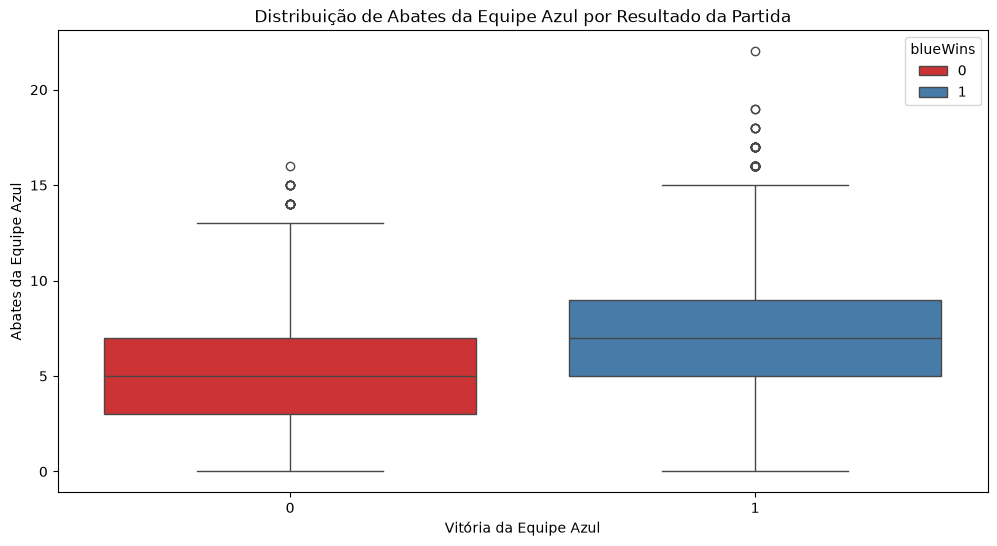

In [10]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=lol,
    x='blueWins',
    y='blueKills',
    hue='blueWins',
    palette='Set1'
)

plt.xlabel('Vitória da Equipe Azul')
plt.ylabel('Abates da Equipe Azul')
plt.title('Distribuição de Abates da Equipe Azul por Resultado da Partida')
plt.show()

### Análise da Distribuição de Abates

O boxplot apresenta a distribuição do número de abates da equipe azul (`blueKills`) de acordo com o resultado da partida (`blueWins`).

É possível observar que as partidas vencidas pela equipe azul apresentam uma **mediana de abates maior**, em torno de 7, enquanto nas partidas perdidas a mediana fica próxima de 5. Além disso, a distribuição das vitórias apresenta uma maior concentração de partidas com números elevados de abates.

Também foram identificados alguns valores estatisticamente classificados como outliers, principalmente nas partidas em que a equipe azul venceu. Entretanto, esses valores são **plausíveis dentro da dinâmica de uma partida de League of Legends** e não indicam necessariamente erros ou inconsistências nos dados. Por esse motivo, os valores extremos foram mantidos.

De maneira geral, o gráfico sugere uma **relação entre um maior número de abates da equipe azul e a probabilidade de vitória**, embora os abates, isoladamente, não sejam suficientes para determinar o resultado de uma partida.


([0, 1, 2],
 [Text(0, 0, '10k-15k'), Text(1, 0, '15k-20k'), Text(2, 0, '20k-25k')])

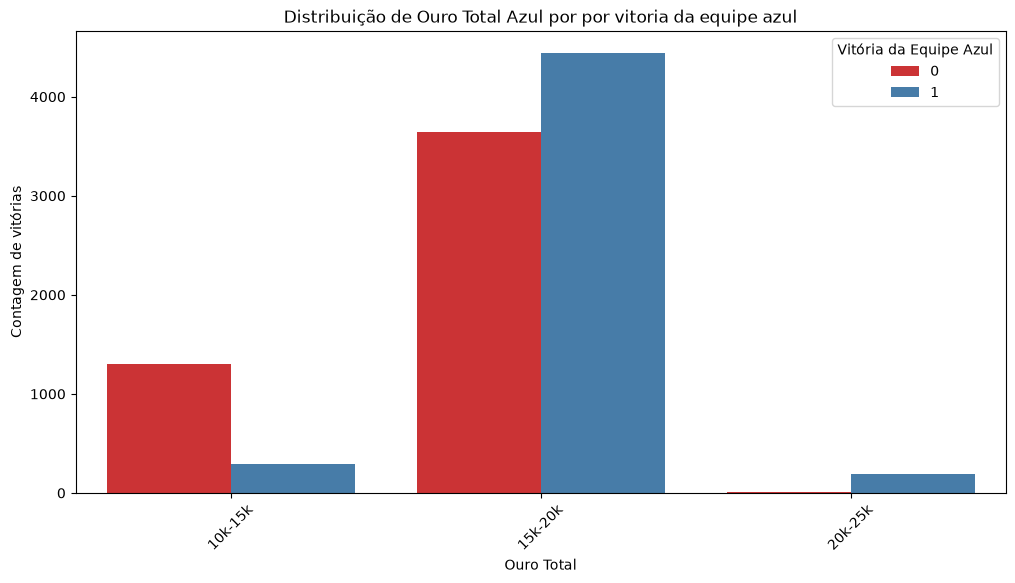

In [11]:
bins = [10000, 15000, 20000, 25000]
labels = ['10k-15k', '15k-20k', '20k-25k']


lol_bins = lol.copy()

lol_bins['blueTotalGold'] = pd.cut(lol_bins['blueTotalGold'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(12,6))
sns.countplot(data=lol_bins, x='blueTotalGold', hue='blueWins', palette='Set1')
plt.xlabel('Ouro Total')
plt.ylabel('Contagem de vitórias')
plt.legend(title='Vitória da Equipe Azul', loc='upper right')
plt.title('Distribuição de Ouro Total Azul por por vitoria da equipe azul')
plt.xticks(rotation=45)




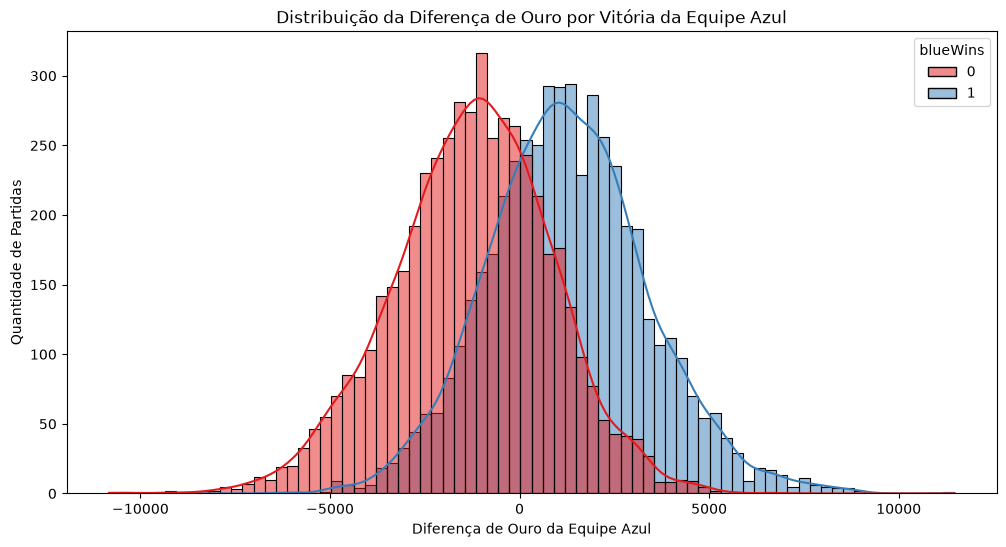

In [12]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=lol,
    x='blueGoldDiff',
    hue='blueWins',
    kde=True,
    palette='Set1'
)

plt.xlabel('Diferença de Ouro da Equipe Azul')
plt.ylabel('Quantidade de Partidas')
plt.title('Distribuição da Diferença de Ouro por Vitória da Equipe Azul')
plt.show()

### Análise da Diferença de Ouro

O gráfico apresenta a distribuição da diferença de ouro da equipe azul (`blueGoldDiff`) de acordo com o resultado da partida (`blueWins`).

É possível observar uma clara diferença entre os grupos. Nas partidas em que a equipe azul **perdeu (`blueWins = 0`)**, a distribuição está mais concentrada em valores negativos, indicando que a equipe vermelha possuía vantagem em ouro. Já nas partidas em que a equipe azul **venceu (`blueWins = 1`)**, a distribuição está deslocada para valores positivos, indicando maior vantagem econômica da equipe azul.

Apesar de existir uma sobreposição das distribuições próxima a zero, o gráfico demonstra uma forte relação entre a diferença de ouro e o resultado da partida. Quanto maior a vantagem de ouro da equipe azul, maior tende a ser a ocorrência de vitórias da equipe azul.

Essa variável se mostra, portanto, relevante para a análise do resultado das partidas e poderá apresentar importância significativa nas etapas posteriores de modelagem preditiva.

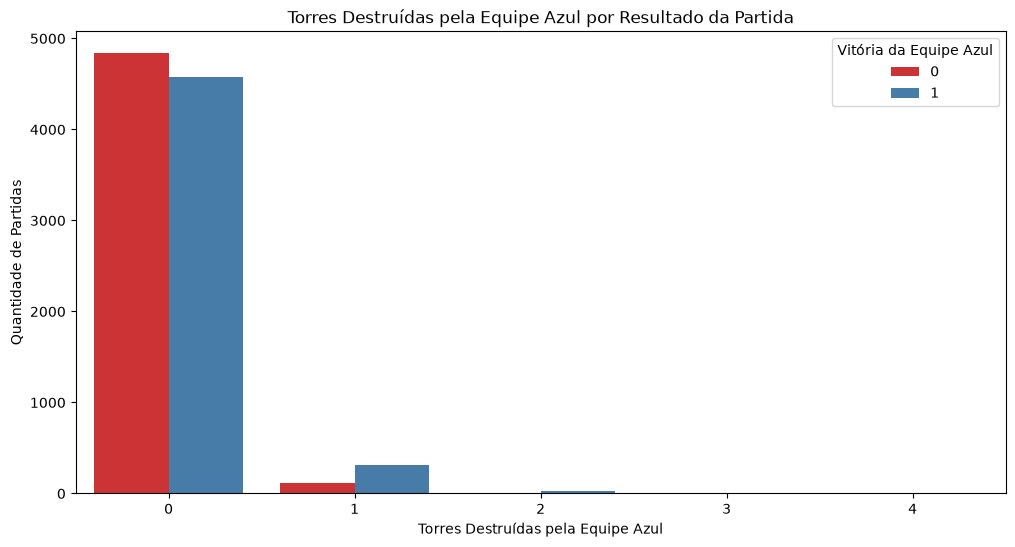

In [13]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=lol,
    x='blueTowersDestroyed',
    hue='blueWins',
    palette='Set1'
)

plt.xlabel('Torres Destruídas pela Equipe Azul')
plt.ylabel('Quantidade de Partidas')
plt.title('Torres Destruídas pela Equipe Azul por Resultado da Partida')
plt.legend(title='Vitória da Equipe Azul')
plt.show()

### Análise de Torres Destruídas

O gráfico apresenta a quantidade de torres destruídas pela equipe azul (`blueTowersDestroyed`) em relação ao resultado da partida (`blueWins`).

É possível observar que a grande maioria das partidas terminou com **nenhuma torre destruída pela equipe azul**. Entre as partidas em que a equipe azul destruiu pelo menos uma torre, há uma maior ocorrência de **vitórias (`blueWins = 1`)**, principalmente quando foram destruídas duas ou mais torres.

Esse comportamento sugere que a conquista de objetivos no mapa está relacionada ao resultado da partida. Embora destruir torres não determine isoladamente uma vitória, a maior presença de vitórias entre as partidas com mais torres destruídas indica que o controle de objetivos pode contribuir para o sucesso da equipe.

A variável será mantida para as próximas etapas, podendo ser utilizada posteriormente na construção do modelo preditivo.


# ⚙️ 5. Preparação para modelagem

Com os dados tratados e analisados, será realizada a preparação do conjunto de dados para a aplicação dos modelos de Machine Learning. Nesta etapa, serão selecionadas as variáveis relevantes, realizadas as transformações necessárias e separados os dados para treinamento e avaliação dos modelos.

O objetivo é garantir que os dados estejam adequadamente estruturados para que os modelos possam ser treinados e avaliados de forma consistente.

In [14]:
# Começando dropando a coluna 'gameid' do dataset, pois ela não é relevante para a análise.

lol = lol.drop(['gameId'], axis=1)

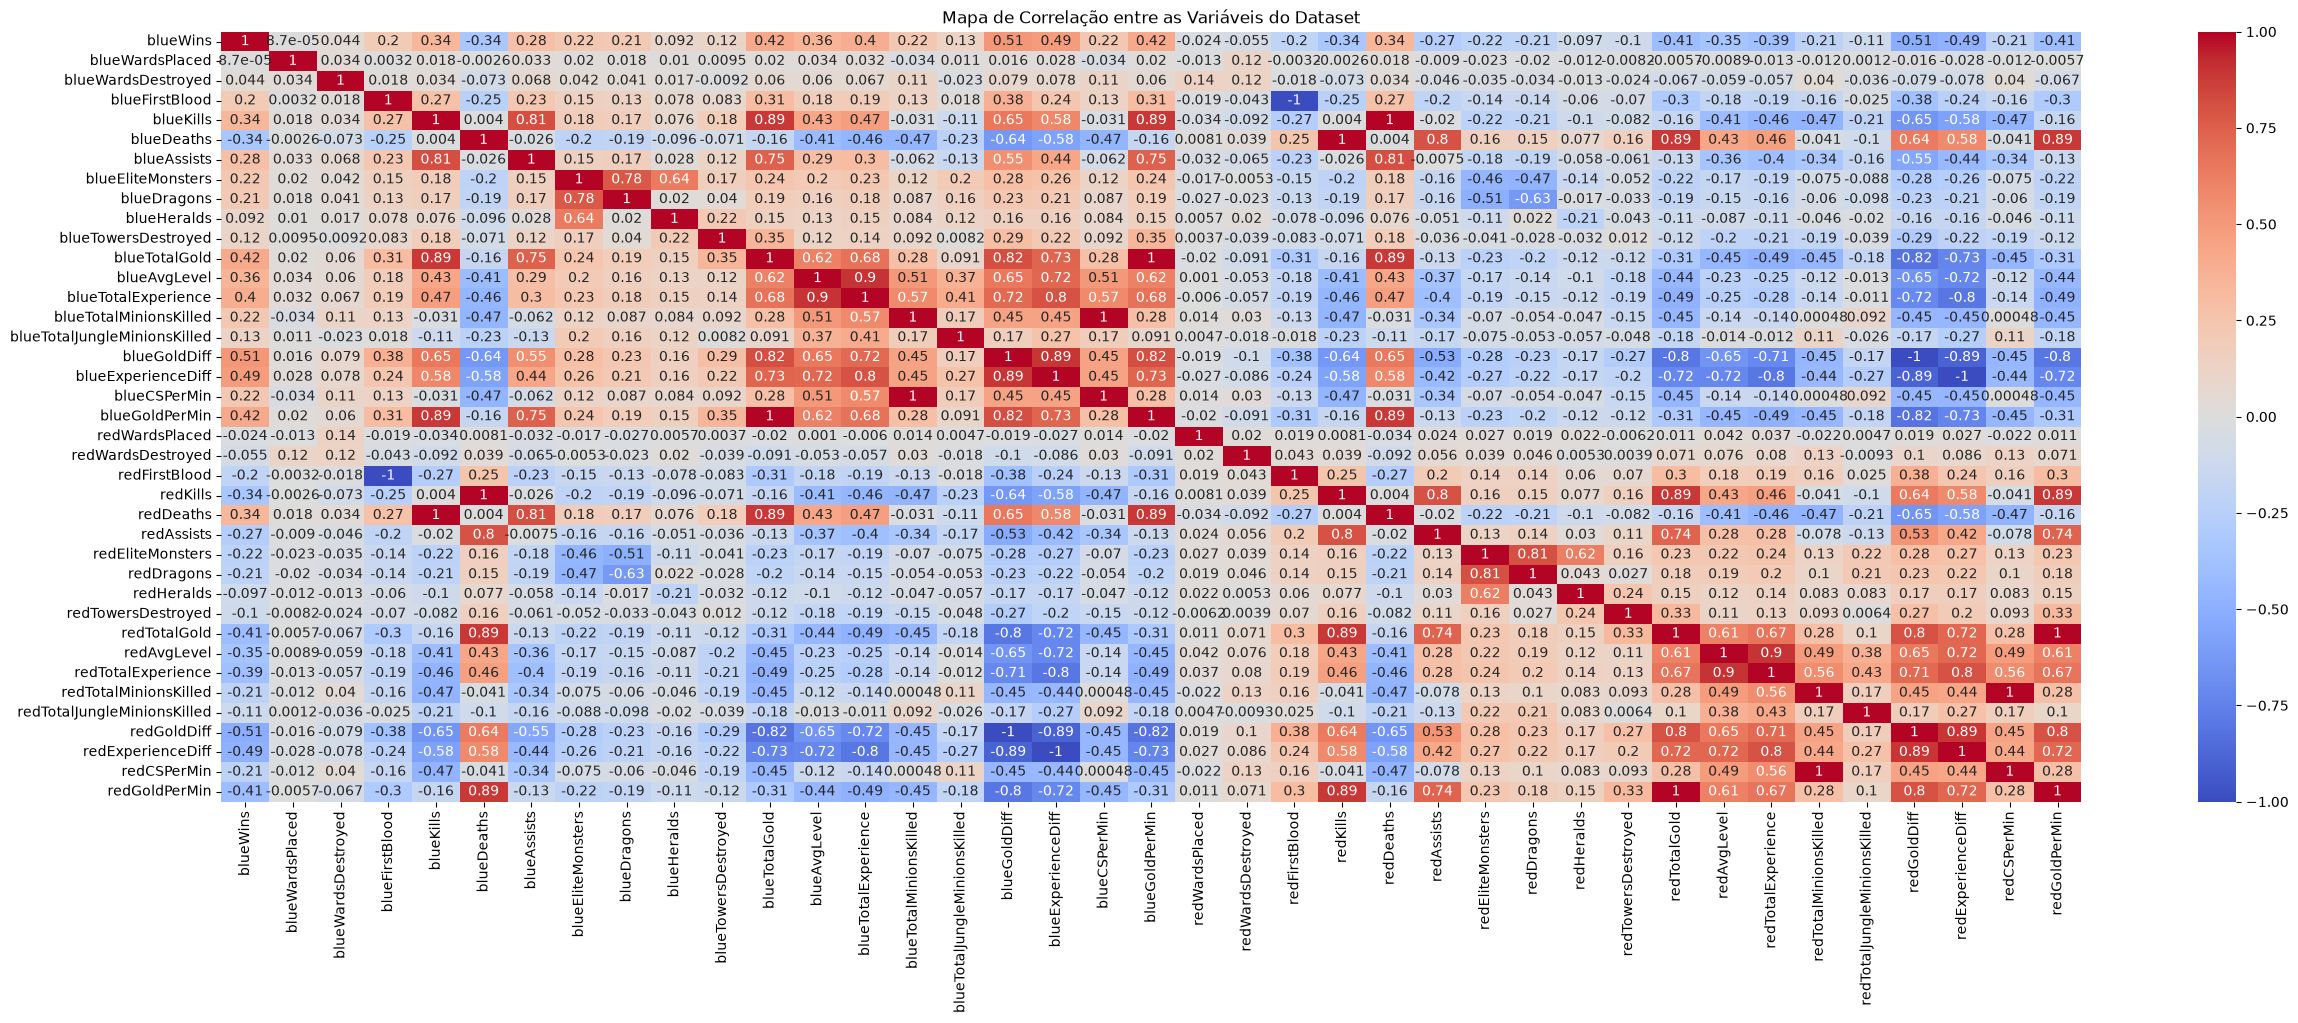

In [15]:
correlacao = lol.corr()

plt.figure(figsize=(30, 10))
plt.title('Mapa de Correlação entre as Variáveis do Dataset')
sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.show()

## 🔄 Separação das Variáveis: `Diff` e `No Diff`

Para avaliar qual representação das informações apresenta melhor desempenho preditivo, foram criadas duas versões do dataset.

### 📊 Dataset `Diff`

Nesta versão, as informações das equipes **Blue e Red são combinadas em variáveis de diferença**, representando a vantagem de uma equipe em relação à outra.

As diferenças são calculadas pela fórmula:

`Diferença = Blue - Red`

Por exemplo:

* `blueKills` e `redKills` → `killDiff`
* `blueAssists` e `redAssists` → `assistsDiff`
* `blueTotalGold` e `redTotalGold` → `totalGoldDiff`

Essa abordagem reduz a quantidade de variáveis e facilita a interpretação da vantagem da equipe Blue em cada aspecto da partida.

### 📋 Dataset `No Diff`

Nesta versão, as informações de cada equipe são **mantidas separadamente**, preservando as características individuais de Blue e Red.

Por exemplo:

* `blueKills` e `redKills`
* `blueAssists` e `redAssists`
* `blueTotalGold` e `redTotalGold`

Dessa forma, o modelo recebe diretamente as informações de cada equipe, permitindo que ele próprio identifique as relações entre as características de Blue e Red.

### 🎯 Objetivo da comparação

As duas representações serão utilizadas nos mesmos modelos de Machine Learning e avaliadas com as mesmas métricas.

O objetivo é verificar experimentalmente se a transformação das variáveis em diferenças apresenta alguma vantagem em relação à utilização das informações separadas por equipe.

Essa comparação permite avaliar não apenas o desempenho dos modelos, mas também o impacto da **engenharia de atributos e da redução de dimensionalidade** na capacidade preditiva.


In [16]:
# Criando uma copiá do dataset para criar uma versão com somente as diff, e depois outro com as colunas sem o diff e dados das duas equipes, para testar qual dos dois datasets é mais relevante para o modelo de machine learning.
lol_diff = lol.copy()

# Transformando colunas que se explicam em uma só

lol_diff['killDiff'] = lol_diff['blueKills'] - lol_diff['redKills']
lol_diff['assistsDiff'] = lol_diff['blueAssists'] - lol_diff['redAssists']
lol_diff['totalGoldDiff'] = lol_diff['blueTotalGold'] - lol_diff['redTotalGold']
lol_diff['dragonDiff'] = lol_diff['blueDragons'] - lol_diff['redDragons']
lol_diff['totalMinionsKilledDiff'] = lol_diff['blueTotalMinionsKilled'] - lol_diff['redTotalMinionsKilled']
lol_diff['totalExperienceDiff'] = lol_diff['blueTotalExperience'] - lol_diff['redTotalExperience']
lol_diff['eliteMonstersDiff'] = lol_diff['blueEliteMonsters'] - lol_diff['redEliteMonsters']
lol_diff['heraldsDiff'] = lol_diff['blueHeralds'] - lol_diff['redHeralds']
lol_diff['towersDestroyedDiff'] = lol_diff['blueTowersDestroyed'] - lol_diff['redTowersDestroyed']
lol_diff['wardsPlacedDiff'] = lol_diff['blueWardsPlaced'] - lol_diff['redWardsPlaced']
lol_diff['wardsDestroyedDiff'] = lol_diff['blueWardsDestroyed'] - lol_diff['redWardsDestroyed']
lol_diff['avgLevelDiff'] = lol_diff['blueAvgLevel'] - lol_diff['redAvgLevel']
lol_diff['CSPerMinDiff'] = lol_diff['blueCSPerMin'] - lol_diff['redCSPerMin']

lol_diff = lol_diff.drop(['blueKills', 'redKills',
                'blueDeaths', 'redDeaths', 
                'blueAssists', 'redAssists', 
                'blueTotalGold', 'redTotalGold',
                'blueGoldPerMin', 'redGoldPerMin',
                'blueDragons', 'redDragons',
                'blueTotalMinionsKilled', 'redTotalMinionsKilled',
                'blueEliteMonsters', 'redEliteMonsters',
                'blueHeralds', 'redHeralds',
                'blueTowersDestroyed', 'redTowersDestroyed',
                'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled', # Não criei o diff pois tem uma correlação muito alta com a coluna 'CSPerMinDiff', literalmente 1.0
                'blueWardsPlaced', 'redWardsPlaced',
                'blueWardsDestroyed', 'redWardsDestroyed',
                'blueGoldDiff', 'redGoldDiff',
                'blueTotalExperience', 'redTotalExperience',
                'blueExperienceDiff', 'redExperienceDiff',
                'blueAvgLevel', 'redAvgLevel',
                'blueCSPerMin', 'redCSPerMin'], axis=1)

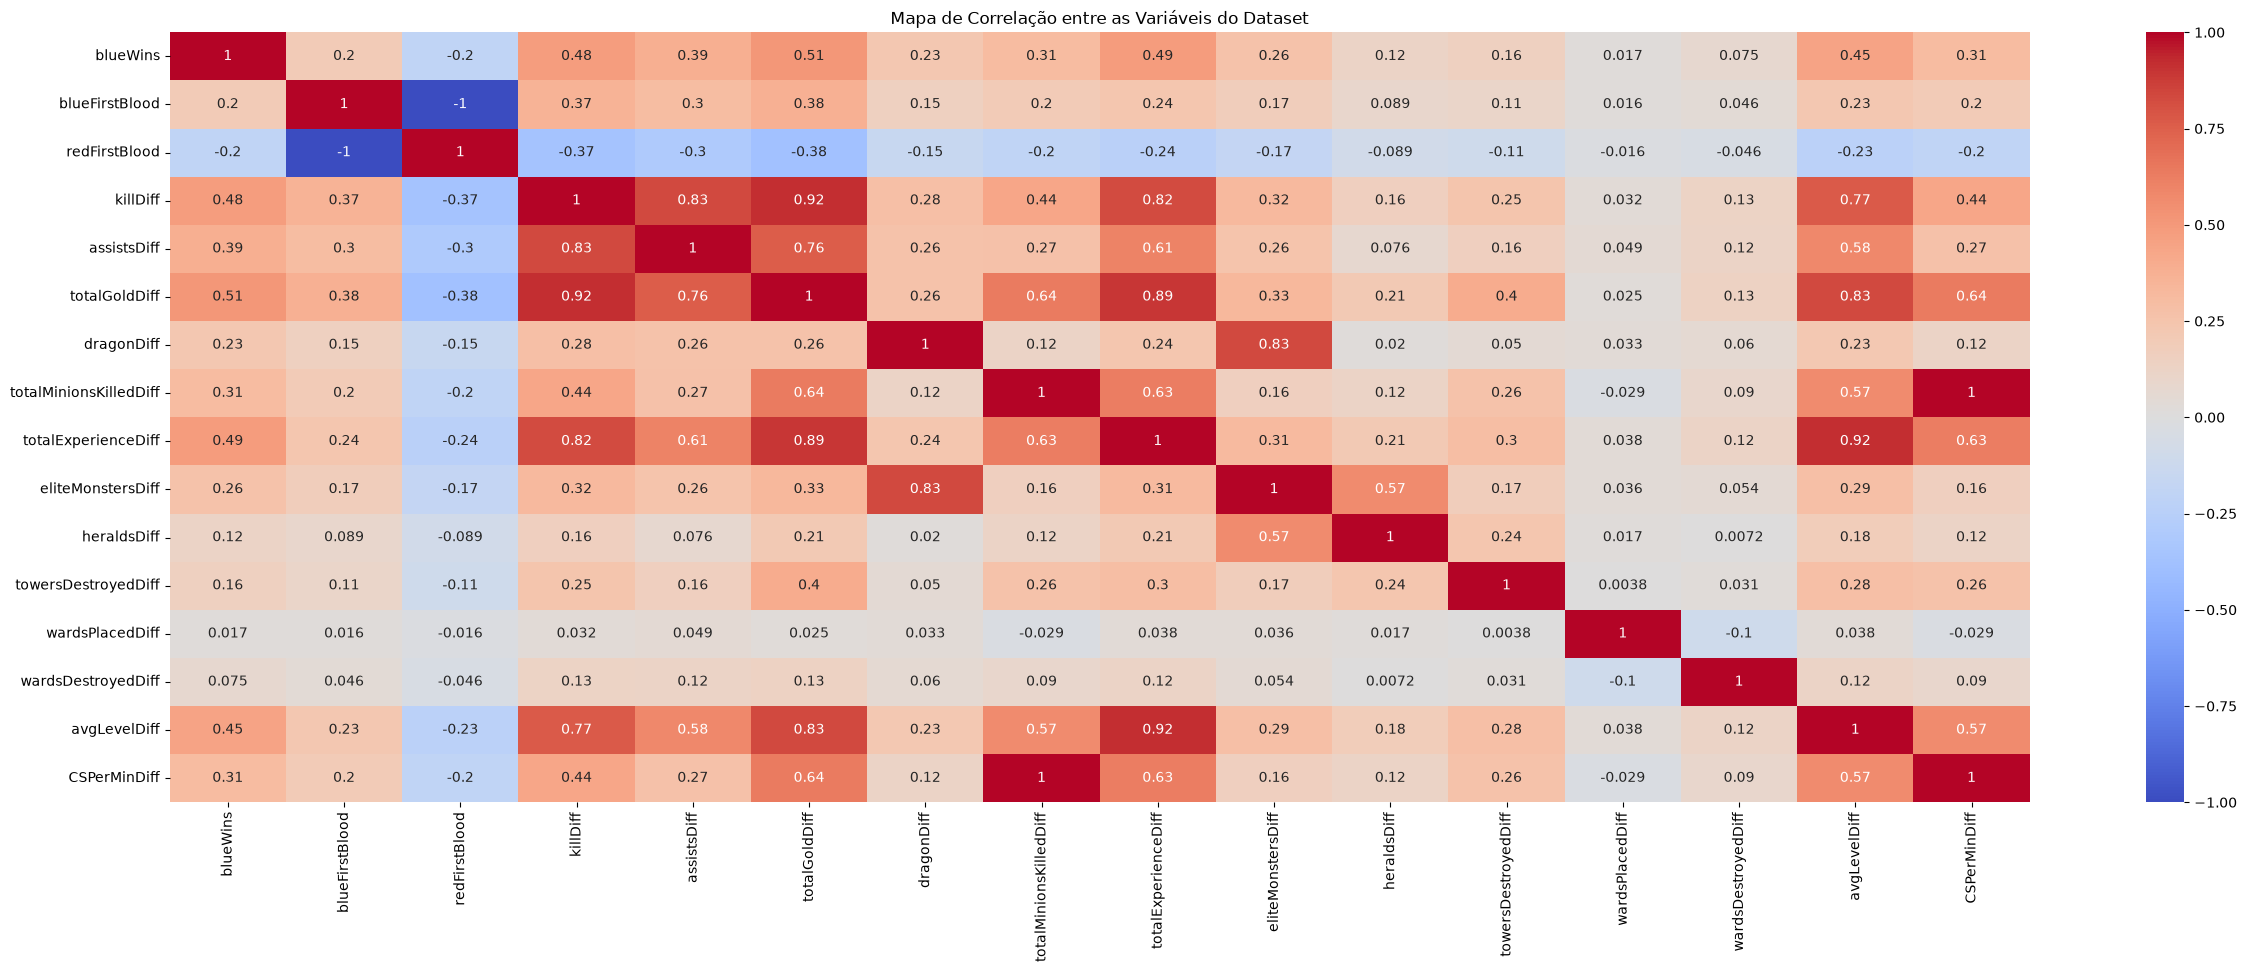

In [17]:
correlacao_diff = lol_diff.corr()

plt.figure(figsize=(30, 10))
plt.title('Mapa de Correlação entre as Variáveis do Dataset')
sns.heatmap(correlacao_diff, annot=True, cmap='coolwarm')
plt.show()

In [18]:
# Transformando a coluna 'blueFirstBlood' em uma coluna mais genérica chamada 'firstBlood', que indica se a equipe azul conseguiu o primeiro abate na partida.

lol_diff['firstBlood'] = lol['blueFirstBlood']
lol_diff = lol_diff.drop(['blueFirstBlood', 'redFirstBlood'], axis=1)

In [19]:
# Criando uma copiá do dataset para criar uma versão com somente as colunas sem o diff e dados das duas equipes, para testar qual dos dois datasets é mais relevante para o modelo de machine learning.

lol_no_diff = lol.copy()

# Dropando colunas que se explicam em uma só, para evitar multicolinearidade no modelo de machine learning.
lol_no_diff = lol_no_diff.drop(['blueGoldDiff', 'redGoldDiff', 'blueExperienceDiff', 'redExperienceDiff',
                                'blueDeaths', 'redDeaths', 'blueGoldPerMin', 'redGoldPerMin',
                                'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled',
                                'blueCSPerMin', 'redCSPerMin'
                                ], axis=1)


# Transformando a coluna 'blueFirstBlood' em uma coluna mais genérica chamada 'firstBlood', que indica se a equipe azul conseguiu o primeiro abate na partida.
lol_no_diff = lol_no_diff.rename(columns={'blueFirstBlood': 'firstBlood'})
lol_no_diff = lol_no_diff.drop(columns=['redFirstBlood'])


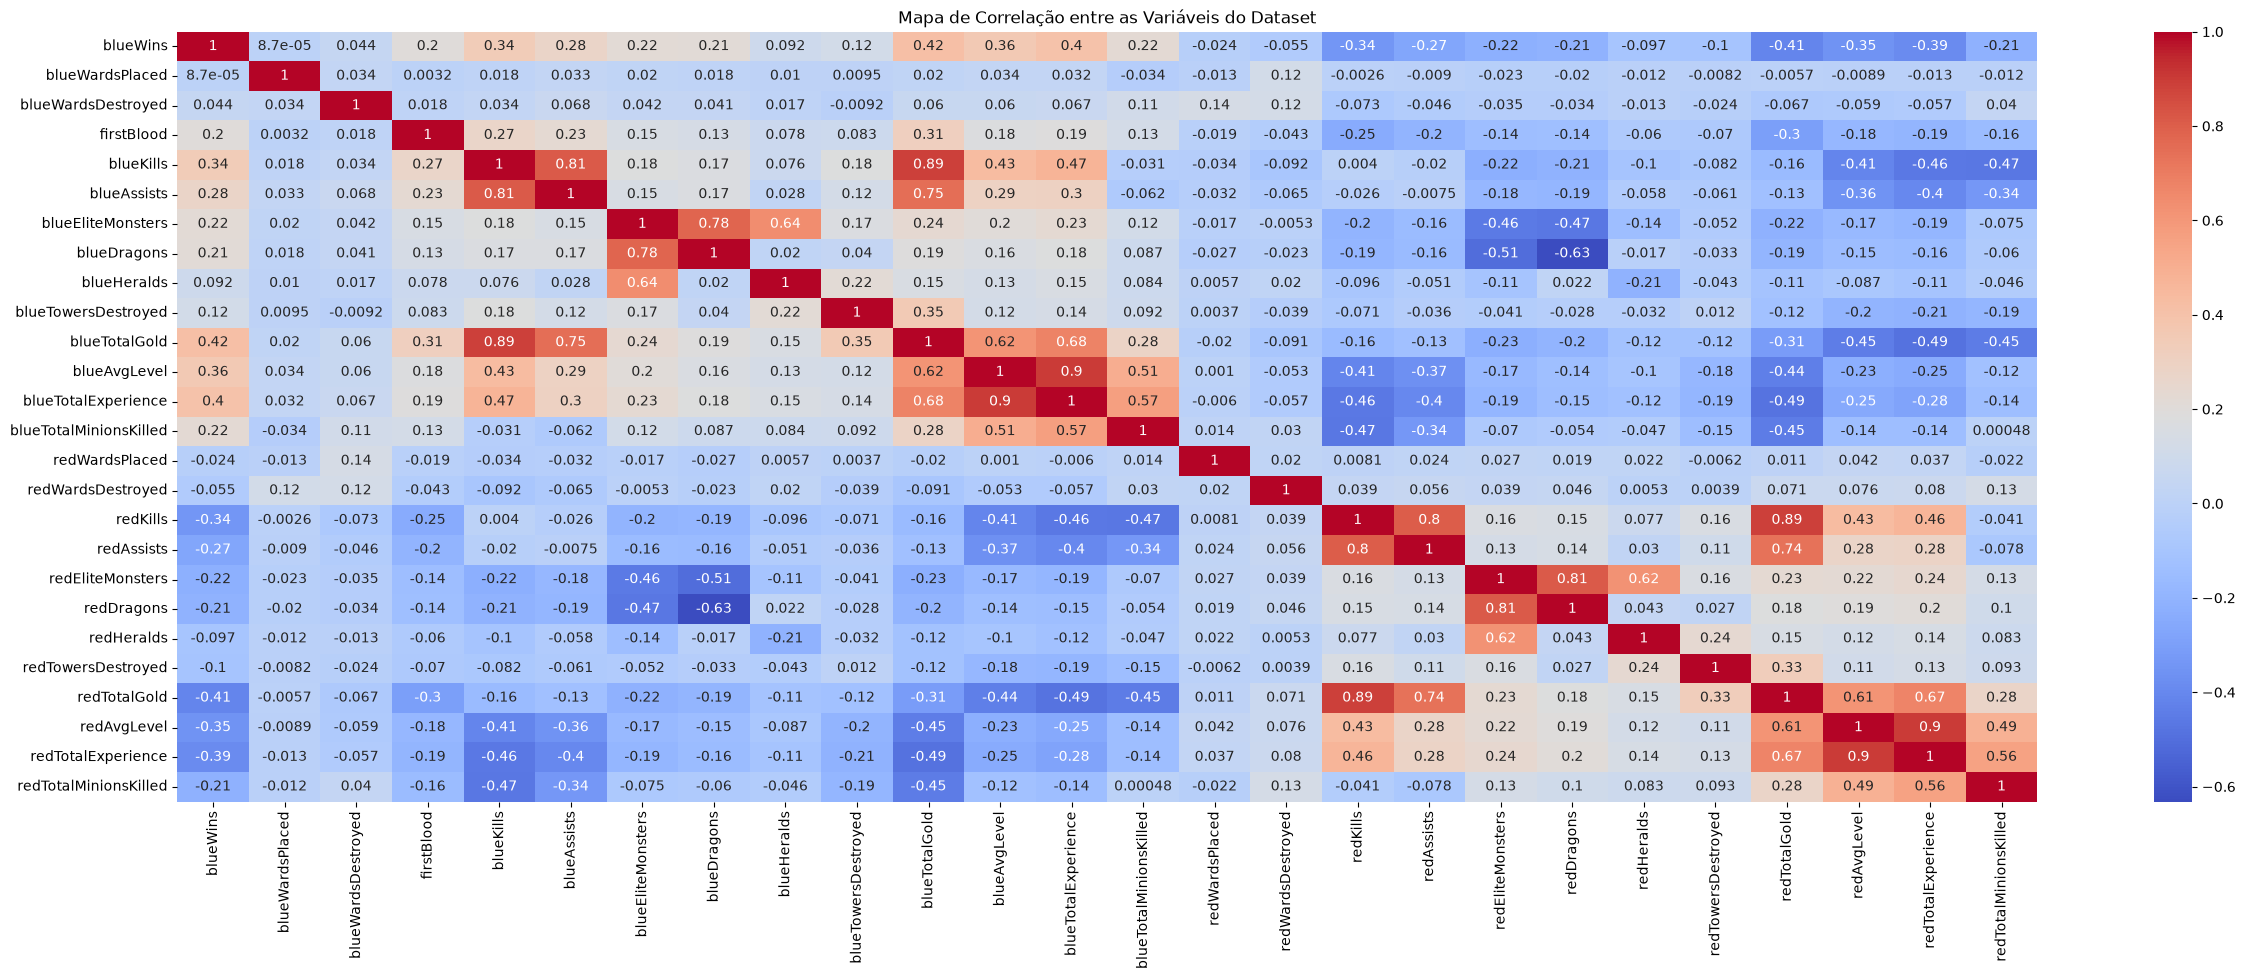

In [20]:
correlacao_no_diff = lol_no_diff.corr()

plt.figure(figsize=(30, 10))
plt.title('Mapa de Correlação entre as Variáveis do Dataset')
sns.heatmap(correlacao_no_diff, annot=True, cmap='coolwarm')
plt.show()

## 🧪 Separação dos Dados em Treino e Teste

Após a etapa de preparação e seleção das variáveis, os dados serão divididos em dois conjuntos: **treino** e **teste**.

O conjunto de **treino** será utilizado para ajustar os modelos de Machine Learning, permitindo que eles aprendam os padrões presentes nos dados. Já o conjunto de **teste** será mantido separado durante o treinamento e utilizado posteriormente para avaliar o desempenho dos modelos em dados que não foram utilizados no aprendizado.

Essa separação é importante para verificar se o modelo consegue **generalizar para novos dados**, evitando uma avaliação baseada apenas nas informações que ele já conhece.

Para garantir uma comparação justa entre as diferentes versões do dataset (`Diff` e `No Diff`), a mesma divisão entre treino e teste será utilizada em ambos os conjuntos.

A variável `blueWins` será utilizada como **variável alvo (target)**, enquanto as demais variáveis selecionadas serão utilizadas como **features** para a previsão do resultado da partida.


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_diff = lol_diff.drop('blueWins', axis=1)

y_diff = lol_diff['blueWins']

In [23]:
X_train_diff, X_test_diff, y_train_diff, y_test_diff = train_test_split(X_diff, y_diff, test_size=0.2, random_state=42)

In [24]:
X_train_diff.head()

,killDiff,assistsDiff,totalGoldDiff,dragonDiff,totalMinionsKilledDiff,totalExperienceDiff,eliteMonstersDiff,heraldsDiff,towersDestroyedDiff,wardsPlacedDiff,wardsDestroyedDiff,avgLevelDiff,CSPerMinDiff,firstBlood
6392,-2,5,-3077,1,-61,-3160,0,-1,-1,2,0,-0.6,-6.1,1
6821,-5,-1,-2494,0,-30,-996,0,0,0,22,2,-0.2,-3.0,1
5753,3,1,283,-1,-36,165,-1,0,0,59,3,0.2,-3.6,1
7332,-3,-4,-816,-1,7,172,-1,0,0,-19,0,0.2,0.7,0
1055,3,7,2850,1,16,1646,2,1,0,-32,2,0.6,1.6,1


In [25]:
X_no_diff = lol_no_diff.drop('blueWins', axis=1)

y_no_diff = lol_no_diff['blueWins']

In [26]:
X_train_no_diff, X_test_no_diff, y_train_no_diff, y_test_no_diff = train_test_split(X_no_diff, y_no_diff, test_size=0.2, random_state=42)

In [27]:
X_train_no_diff.head()

,blueWardsPlaced,blueWardsDestroyed,firstBlood,blueKills,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,redWardsPlaced,redWardsDestroyed,redKills,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled
6392,16,1,1,6,10,1,1,0,0,15388,6.4,15544,153,14,1,8,5,1,0,1,1,18465,7.0,18704,214
6821,36,4,1,1,2,0,0,0,0,13981,6.6,16753,220,14,2,6,3,0,0,0,0,16475,6.8,17749,250
5753,73,3,1,10,10,0,0,0,0,16818,6.8,16676,183,14,0,7,9,1,1,0,0,16535,6.6,16511,219
7332,13,3,0,4,5,0,0,0,0,15614,7.0,17578,241,32,3,7,9,1,1,0,0,16430,6.8,17406,234
1055,15,2,1,4,7,2,1,1,0,17320,7.4,18965,264,47,0,1,0,0,0,0,0,14470,6.8,17319,248


In [28]:
y_diff.value_counts()

blueWins
0    4949
1    4930
Name: count, dtype: int64

# 🤖 6. Aplicação dos modelos

Nesta etapa, serão aplicados modelos de Machine Learning adequados ao problema proposto. Os modelos serão treinados utilizando os dados preparados anteriormente, buscando identificar padrões que possam auxiliar na compreensão ou previsão do resultado das partidas.

Diferentes abordagens poderão ser testadas para comparar seu desempenho e identificar quais apresentam melhores resultados para o conjunto de dados utilizado.


## XGBoost - Treinamento dos Modelos Base


In [29]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

XGBmodelDiff = XGBClassifier(random_state=42,eval_metric='logloss')

XGBmodelNoDiff = XGBClassifier(random_state=42,eval_metric='logloss')

In [30]:
pipeline_xgb_diff = Pipeline([('modelo', XGBmodelDiff)])

In [31]:
pipeline_xgb_no_diff = Pipeline([('modelo', XGBmodelNoDiff)])

In [32]:
pipeline_xgb_diff.fit(X_train_diff, y_train_diff)

y_pred_diff = pipeline_xgb_diff.predict(X_test_diff)

In [33]:
pipeline_xgb_no_diff.fit(X_train_no_diff, y_train_no_diff)

y_pred_no_diff = pipeline_xgb_no_diff.predict(X_test_no_diff)

In [34]:
y_prob_diff_no_opt = pipeline_xgb_diff.predict_proba(X_test_diff)[:, 1]

y_prob_no_diff_no_opt = pipeline_xgb_no_diff.predict_proba(X_test_no_diff)[:, 1]

### Hyperparâmetros e Cross-Validation

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'modelo__n_estimators': [100, 200, 300],
    'modelo__max_depth': [3, 5, 7],
    'modelo__learning_rate': [0.01, 0.1, 0.2],
    'modelo__subsample': [0.8, 1.0]
}

In [36]:
grid_xgb_diff = GridSearchCV(
    pipeline_xgb_diff,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb_no_diff = GridSearchCV(
    pipeline_xgb_no_diff,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [37]:
grid_xgb_diff.fit(X_train_diff, y_train_diff)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__learning_rate': [0.01, 0.1, ...], 'modelo__max_depth': [3, 5, ...], 'modelo__n_estimators': [100, 200, ...], 'modelo__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppor

In [38]:
grid_xgb_no_diff.fit(X_train_no_diff, y_train_no_diff)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__learning_rate': [0.01, 0.1, ...], 'modelo__max_depth': [3, 5, ...], 'modelo__n_estimators': [100, 200, ...], 'modelo__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppor

In [39]:
print('Melhores parâmetros - Diff:')
print(grid_xgb_diff.best_params_)

print('Melhores parâmetros - No Diff:')
print(grid_xgb_no_diff.best_params_)

Melhores parâmetros - Diff:
{'modelo__learning_rate': 0.01, 'modelo__max_depth': 3, 'modelo__n_estimators': 200, 'modelo__subsample': 0.8}
Melhores parâmetros - No Diff:
{'modelo__learning_rate': 0.01, 'modelo__max_depth': 3, 'modelo__n_estimators': 300, 'modelo__subsample': 1.0}


In [40]:
print(grid_xgb_diff.best_score_)

0.7311163420043394


In [41]:
print(grid_xgb_no_diff.best_score_)

0.7297230562294332


In [42]:
melhor_xgb_diff = grid_xgb_diff.best_estimator_

melhor_xgb_no_diff = grid_xgb_no_diff.best_estimator_

In [43]:
melhor_xgb_diff.fit(X_train_diff, y_train_diff)

melhor_xgb_no_diff.fit(X_train_no_diff, y_train_no_diff)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[<U22](25,)","['blueWardsPlaced','blueWardsDestroyed','firstBlood',...,'redAvgLevel', 'redTotalExperience','redTotalMinionsKilled']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [44]:
m_y_pred_diff = melhor_xgb_diff.predict(X_test_diff)

m_y_pred_no_diff = melhor_xgb_no_diff.predict(X_test_no_diff)

## Random Forest - Treinamento dos Modelos

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
RFDiff = RandomForestClassifier(random_state=42)
RFnoDiff = RandomForestClassifier(random_state=42)

In [47]:
RFDiff_pipeline = Pipeline([('modelo', RFDiff)])

RFnoDiff_pipeline = Pipeline([('modelo', RFnoDiff)])

In [48]:
RFDiff_pipeline.fit(X_train_diff, y_train_diff)

RFnoDiff_pipeline.fit(X_train_no_diff, y_train_no_diff)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['blueWardsPlaced','blueWardsDestroyed','firstBlood',...,'redAvgLevel', 'redTotalExperience','redTotalMinionsKilled']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [49]:
RFy_pred_diff = RFDiff_pipeline.predict(X_test_diff)

RFy_pred_no_diff = RFnoDiff_pipeline.predict(X_test_no_diff)

In [50]:
RFy_prob_diff_no_opt = RFDiff_pipeline.predict_proba(X_test_diff)[:, 1]

RFy_prob_no_diff_no_opt = RFnoDiff_pipeline.predict_proba(X_test_no_diff)[:, 1]

### Hyperparâmetros e Cross-Validation

In [51]:
param_grid_rf = {
    'modelo__n_estimators': [100, 200, 300],
    'modelo__max_depth': [None, 10, 20, 30],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__min_samples_leaf': [1, 2, 4],
    'modelo__max_features': ['sqrt', 'log2']
}

In [52]:
grid_rf_diff = GridSearchCV(
    RFDiff_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf_diff.fit(X_train_diff, y_train_diff)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__max_depth': [None, 10, ...], 'modelo__max_features': ['sqrt', 'log2'], 'modelo__min_samples_leaf': [1, 2, ...], 'modelo__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchange

In [53]:
grid_rf_no_diff = GridSearchCV(
    RFnoDiff_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf_no_diff.fit(X_train_no_diff, y_train_no_diff)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__max_depth': [None, 10, ...], 'modelo__max_features': ['sqrt', 'log2'], 'modelo__min_samples_leaf': [1, 2, ...], 'modelo__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchange

In [54]:
print('Melhores parâmetros - Diff:')
print(grid_rf_diff.best_params_)

print('\nMelhores parâmetros - No Diff:')
print(grid_rf_no_diff.best_params_)

Melhores parâmetros - Diff:
{'modelo__max_depth': 10, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}

Melhores parâmetros - No Diff:
{'modelo__max_depth': 10, 'modelo__max_features': 'log2', 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}


In [55]:
print(grid_rf_diff.best_score_)

0.7273209553319082


In [56]:
print(grid_rf_no_diff.best_score_)

0.7295983955035669


In [57]:
melhor_rf_diff = grid_rf_diff.best_estimator_
melhor_rf_no_diff = grid_rf_no_diff.best_estimator_

In [58]:
RF_y_pred_diff = melhor_rf_diff.predict(X_test_diff)
RF_y_pred_no_diff = melhor_rf_no_diff.predict(X_test_no_diff)

In [59]:
RF_prob_diff = melhor_rf_diff.predict_proba(X_test_diff)[:, 1]
RF_prob_no_diff = melhor_rf_no_diff.predict_proba(X_test_no_diff)[:, 1]

# 📏 7. Avaliação dos resultados

Após o treinamento dos modelos, seus desempenhos serão avaliados utilizando métricas apropriadas ao problema. Os resultados obtidos serão comparados para verificar a capacidade dos modelos de representar os padrões encontrados nos dados.

Além do desempenho das métricas, serão considerados os possíveis pontos fortes e limitações de cada abordagem utilizada.

## XGBoost - Métricas de Avaliação

In [60]:
from sklearn.metrics import classification_report

In [61]:
print(classification_report(y_test_diff, y_pred_diff))

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       983
           1       0.71      0.70      0.71       993

    accuracy                           0.71      1976
   macro avg       0.71      0.71      0.71      1976
weighted avg       0.71      0.71      0.71      1976



In [62]:
print(classification_report(y_test_no_diff, y_pred_no_diff))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70       983
           1       0.70      0.68      0.69       993

    accuracy                           0.70      1976
   macro avg       0.70      0.70      0.70      1976
weighted avg       0.70      0.70      0.70      1976



### 📊 Avaliação das Métricas dos Modelos Base

Após o treinamento dos modelos base de **XGBoost**, foram avaliadas as previsões utilizando métricas de classificação como **acurácia, precisão, recall e F1-score**.

### 🔹 `lol_diff`

O modelo apresentou:

* **Accuracy:** 0,71
* **Precision:** 0,70 para a classe 0 e 0,71 para a classe 1
* **Recall:** 0,72 para a classe 0 e 0,70 para a classe 1
* **F1-score:** 0,71 para ambas as classes

Os resultados mostram um desempenho bastante equilibrado entre as classes, indicando que o modelo não apresenta uma tendência significativa a favorecer uma das classes. A diferença entre precisão, recall e F1-score também é pequena, reforçando a consistência das previsões.

### 🔹 `lol_no_diff`

O modelo apresentou:

* **Accuracy:** 0,70
* **Precision:** 0,69 para a classe 0 e 0,70 para a classe 1
* **Recall:** 0,71 para a classe 0 e 0,68 para a classe 1
* **F1-score:** 0,70 para a classe 0 e 0,69 para a classe 1

O desempenho também foi equilibrado entre as classes, porém apresentou resultados ligeiramente inferiores aos obtidos pelo modelo utilizando as variáveis em formato de diferença.

### 🔎 Comparação

A representação `lol_diff` apresentou uma pequena vantagem sobre `lol_no_diff`:

| Modelo        | Accuracy | F1 médio |
| ------------- | -------: | -------: |
| `lol_diff`    | **0,71** | **0,71** |
| `lol_no_diff` |     0,70 |     0,70 |

Neste primeiro teste, a transformação das variáveis para representar a **diferença entre as equipes** apresentou um desempenho ligeiramente superior. Entretanto, essa diferença ainda é pequena, portanto serão realizadas etapas de **otimização dos hiperparâmetros** para verificar se essa vantagem se mantém após o ajuste dos modelos.


In [63]:
print(classification_report(y_test_diff, m_y_pred_diff))

              precision    recall  f1-score   support

           0       0.72      0.74      0.73       983
           1       0.74      0.72      0.73       993

    accuracy                           0.73      1976
   macro avg       0.73      0.73      0.73      1976
weighted avg       0.73      0.73      0.73      1976



In [64]:
print(classification_report(y_test_diff, m_y_pred_diff))

              precision    recall  f1-score   support

           0       0.72      0.74      0.73       983
           1       0.74      0.72      0.73       993

    accuracy                           0.73      1976
   macro avg       0.73      0.73      0.73      1976
weighted avg       0.73      0.73      0.73      1976



### ⚙️ Otimização do Modelo XGBoost

Após a avaliação dos modelos base, foi realizada a otimização do **XGBoost** utilizando o `GridSearchCV`. O processo avaliou diferentes combinações de hiperparâmetros por meio de **validação cruzada com 5 folds (K-Fold Cross-Validation)**, buscando encontrar a configuração que apresentasse o melhor desempenho nos dados de treinamento.

Os principais hiperparâmetros avaliados foram definidos no `param_grid`, permitindo testar diferentes configurações do modelo de forma automatizada.

Após a busca, o melhor modelo foi obtido por meio do `best_estimator_` e utilizado para realizar as previsões no conjunto de teste.

### 📊 Resultado

No conjunto de teste, o modelo otimizado apresentou:

* **Accuracy:** 0,73
* **Precision:** 0,72 para a classe 0 e 0,74 para a classe 1
* **Recall:** 0,74 para a classe 0 e 0,72 para a classe 1
* **F1-score:** 0,73 para ambas as classes

Em comparação com o modelo base, que apresentou **0,71 de acurácia**, o modelo otimizado alcançou **0,73**, indicando uma melhora no desempenho após o ajuste dos hiperparâmetros.

Além disso, as métricas permaneceram equilibradas entre as duas classes, indicando que o modelo não apresenta uma tendência significativa em favorecer uma delas.


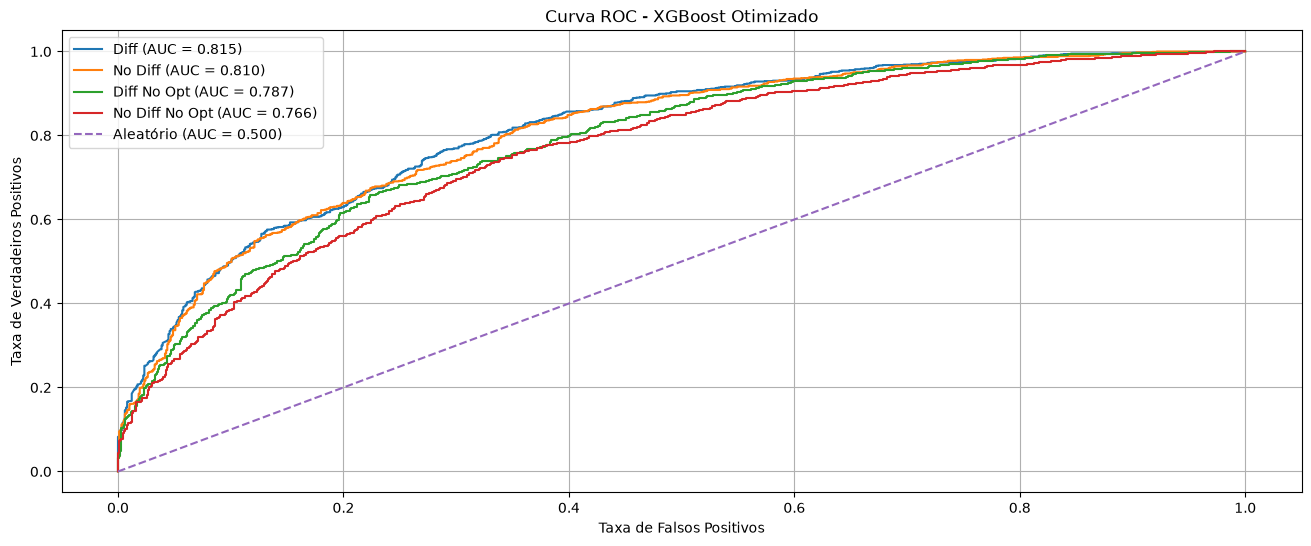

In [65]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades dos modelos Otimizados
y_prob_diff = melhor_xgb_diff.predict_proba(X_test_diff)[:, 1]
y_prob_no_diff = melhor_xgb_no_diff.predict_proba(X_test_no_diff)[:, 1]

# Curvas ROC
fpr_diff, tpr_diff, _ = roc_curve(y_test_diff, y_prob_diff)
fpr_no_diff, tpr_no_diff, _ = roc_curve(y_test_no_diff, y_prob_no_diff)

# AUC
auc_diff = roc_auc_score(y_test_diff, y_prob_diff)
auc_no_diff = roc_auc_score(y_test_no_diff, y_prob_no_diff)

# Probabilidades dos modelos não otimizados definidas la em cima

# Curvas ROC
fpr_diff_no_opt, tpr_diff_no_opt, _ = roc_curve(y_test_diff, y_prob_diff_no_opt)
fpr_no_diff_no_opt, tpr_no_diff_no_opt, _ = roc_curve(y_test_no_diff, y_prob_no_diff_no_opt)

# AUC
auc_diff_no_opt = roc_auc_score(y_test_diff, y_prob_diff_no_opt)
auc_no_diff_no_opt = roc_auc_score(y_test_no_diff, y_prob_no_diff_no_opt)

# Gráfico
plt.figure(figsize=(16, 6))

plt.plot(
    fpr_diff,
    tpr_diff,
    label=f'Diff (AUC = {auc_diff:.3f})'
)

plt.plot(
    fpr_no_diff,
    tpr_no_diff,
    label=f'No Diff (AUC = {auc_no_diff:.3f})'
)

plt.plot(
    fpr_diff_no_opt,
    tpr_diff_no_opt,
    label=f'Diff No Opt (AUC = {auc_diff_no_opt:.3f})'
)

plt.plot(
    fpr_no_diff_no_opt,
    tpr_no_diff_no_opt,
    label=f'No Diff No Opt (AUC = {auc_no_diff_no_opt:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Aleatório (AUC = 0.500)'
)

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - XGBoost Otimizado')
plt.legend()
plt.grid()
plt.show()

### 📈 Comparação das Curvas ROC

Para complementar a avaliação dos modelos, foi analisada a **Curva ROC (Receiver Operating Characteristic)** juntamente com a métrica **AUC (Area Under the Curve)**. Essa análise permite avaliar a capacidade dos modelos de distinguir entre as duas classes considerando diferentes limiares de classificação.

Foram comparados os modelos **XGBoost base e otimizado** para as duas representações do dataset.

### 🔹 Resultados

| Modelo                |       AUC |
| --------------------- | --------: |
| **Diff otimizado**    | **0,815** |
| **No Diff otimizado** | **0,810** |
| Diff base             |     0,787 |
| No Diff base          |     0,766 |

Os resultados mostram que os modelos otimizados apresentaram uma capacidade de discriminação superior aos modelos base. O modelo **Diff otimizado** apresentou o melhor resultado, com **AUC de 0,815**, seguido pelo **No Diff otimizado**, com **0,810**.

Além disso, a comparação entre as representações indica uma pequena vantagem do formato **Diff**, tanto no modelo base quanto no otimizado.

A linha tracejada representa um classificador aleatório, com **AUC = 0,500**. Como todos os modelos apresentaram valores significativamente superiores a esse resultado, observa-se uma capacidade relevante de distinguir entre vitórias e derrotas da equipe Blue.

### 🎯 Conclusão

A análise da curva ROC reforça os resultados obtidos anteriormente: a representação por **diferenças entre as equipes (`Diff`) apresentou o melhor desempenho**, embora a diferença para `No Diff` seja pequena.

A otimização também trouxe uma melhora clara na capacidade de discriminação, principalmente no modelo `No Diff`, que passou de **0,766 para 0,810** de AUC.


## Random Forest - Métricas de Avaliação

In [66]:
print(classification_report(y_test_diff, RFy_pred_diff))

              precision    recall  f1-score   support

           0       0.71      0.73      0.72       983
           1       0.72      0.71      0.72       993

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



In [67]:
print(classification_report(y_test_no_diff, RFy_pred_no_diff))

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       983
           1       0.72      0.70      0.71       993

    accuracy                           0.71      1976
   macro avg       0.71      0.71      0.71      1976
weighted avg       0.71      0.71      0.71      1976



### 🌲 Avaliação do Modelo Random Forest

Após o treinamento do modelo **Random Forest**, foram avaliadas as previsões para as duas representações do dataset: `lol_diff` e `lol_no_diff`.

### 🔹 `lol_diff`

O modelo apresentou:

* **Accuracy:** 0,72
* **Precision:** 0,71 para a classe 0 e 0,72 para a classe 1
* **Recall:** 0,73 para a classe 0 e 0,71 para a classe 1
* **F1-score:** 0,72 para ambas as classes

### 🔹 `lol_no_diff`

O modelo apresentou:

* **Accuracy:** 0,71
* **Precision:** 0,70 para a classe 0 e 0,72 para a classe 1
* **Recall:** 0,72 para a classe 0 e 0,70 para a classe 1
* **F1-score:** 0,71 para ambas as classes

### 📊 Comparação

A representação `lol_diff` apresentou um desempenho ligeiramente superior à `lol_no_diff`, com **0,72 contra 0,71 de acurácia** e F1-score médio equivalente aos respectivos valores de acurácia.

Assim como observado no XGBoost, a utilização das variáveis como **diferenças entre as equipes** apresentou uma pequena vantagem no Random Forest. Os resultados também permaneceram equilibrados entre as classes, sem uma diferença significativa entre precisão e recall.


In [68]:
print(classification_report(y_test_diff, RF_y_pred_diff))

              precision    recall  f1-score   support

           0       0.73      0.73      0.73       983
           1       0.73      0.73      0.73       993

    accuracy                           0.73      1976
   macro avg       0.73      0.73      0.73      1976
weighted avg       0.73      0.73      0.73      1976



In [69]:
print(classification_report(y_test_diff, RF_y_pred_diff))

              precision    recall  f1-score   support

           0       0.73      0.73      0.73       983
           1       0.73      0.73      0.73       993

    accuracy                           0.73      1976
   macro avg       0.73      0.73      0.73      1976
weighted avg       0.73      0.73      0.73      1976



### ⚙️ Otimização do Random Forest

Após a avaliação do modelo base, foi realizada a otimização do **Random Forest** utilizando o `GridSearchCV`, com **validação cruzada de 5 folds** para avaliar diferentes combinações de hiperparâmetros.

O melhor modelo encontrado foi então utilizado para realizar as previsões no conjunto de teste.

### 📊 Resultados

Para a representação `lol_diff`, o modelo otimizado apresentou:

* **Accuracy:** 0,73
* **Precision:** 0,73 para ambas as classes
* **Recall:** 0,73 para ambas as classes
* **F1-score:** 0,73 para ambas as classes

O resultado demonstra um desempenho **equilibrado entre as duas classes**, sem diferença relevante entre precisão e recall.

Em comparação com o Random Forest base, que apresentou **0,72 de acurácia**, a otimização dos hiperparâmetros resultou em uma melhora de **1 ponto percentual**, alcançando 0,73.

A etapa de validação cruzada também permite uma avaliação mais robusta dos hiperparâmetros, reduzindo a dependência de uma única divisão dos dados de treinamento.


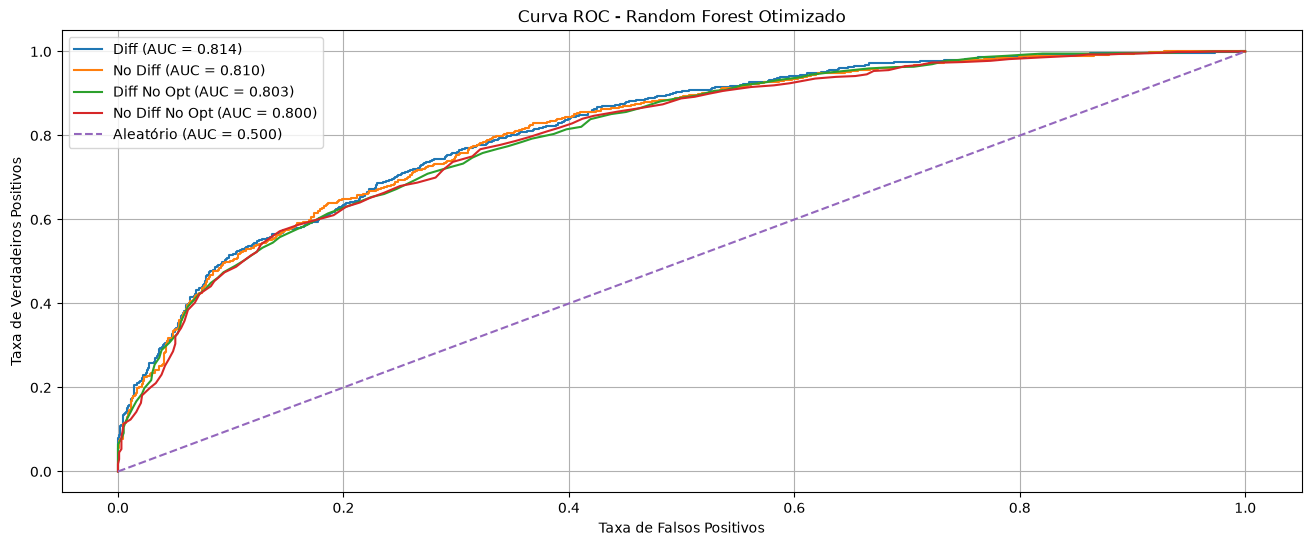

In [70]:
# Probabilidades dos modelos Otimizados
y_prob_diff = melhor_rf_diff.predict_proba(X_test_diff)[:, 1]
y_prob_no_diff = melhor_rf_no_diff.predict_proba(X_test_no_diff)[:, 1]

# Curvas ROC
fpr_diff, tpr_diff, _ = roc_curve(y_test_diff, y_prob_diff)
fpr_no_diff, tpr_no_diff, _ = roc_curve(y_test_no_diff, y_prob_no_diff)

# AUC
auc_diff = roc_auc_score(y_test_diff, y_prob_diff)
auc_no_diff = roc_auc_score(y_test_no_diff, y_prob_no_diff)

# Probabilidades dos modelos não otimizados definidas la em cima

# Curvas ROC
fpr_diff_no_opt, tpr_diff_no_opt, _ = roc_curve(y_test_diff, RFy_prob_diff_no_opt)
fpr_no_diff_no_opt, tpr_no_diff_no_opt, _ = roc_curve(y_test_no_diff, RFy_prob_no_diff_no_opt)

# AUC
auc_diff_no_opt = roc_auc_score(y_test_diff, RFy_prob_diff_no_opt)
auc_no_diff_no_opt = roc_auc_score(y_test_no_diff, RFy_prob_no_diff_no_opt)

# Gráfico
plt.figure(figsize=(16, 6))

plt.plot(
    fpr_diff,
    tpr_diff,
    label=f'Diff (AUC = {auc_diff:.3f})'
)

plt.plot(
    fpr_no_diff,
    tpr_no_diff,
    label=f'No Diff (AUC = {auc_no_diff:.3f})'
)

plt.plot(
    fpr_diff_no_opt,
    tpr_diff_no_opt,
    label=f'Diff No Opt (AUC = {auc_diff_no_opt:.3f})'
)

plt.plot(
    fpr_no_diff_no_opt,
    tpr_no_diff_no_opt,
    label=f'No Diff No Opt (AUC = {auc_no_diff_no_opt:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Aleatório (AUC = 0.500)'
)

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Random Forest Otimizado')
plt.legend()
plt.grid()
plt.show()

### 📈 Comparação das Curvas ROC — Random Forest

Para avaliar a capacidade de discriminação do **Random Forest**, foram comparadas as curvas ROC dos modelos base e otimizados, utilizando as representações `Diff` e `No Diff`.

### 📊 Resultados

| Modelo                |       AUC |
| --------------------- | --------: |
| **Diff otimizado**    | **0,814** |
| **No Diff otimizado** | **0,810** |
| Diff base             |     0,803 |
| No Diff base          |     0,800 |

Os resultados mostram que todos os modelos apresentaram desempenho significativamente superior ao classificador aleatório, representado pela linha tracejada com **AUC = 0,500**.

A representação `Diff` apresentou uma pequena vantagem em relação à `No Diff`, tanto no modelo base quanto no otimizado. Após a otimização, o `Diff` alcançou **AUC de 0,814**, enquanto o `No Diff` alcançou **0,810**.

A diferença entre os modelos base e otimizados foi pequena, indicando que o ajuste dos hiperparâmetros teve **impacto limitado na capacidade de discriminação do Random Forest**. Ainda assim, os resultados permanecem consistentes e indicam uma boa capacidade do modelo em distinguir entre vitórias e derrotas da equipe Blue.


# 🔎 8. Análise dos Erros



Após o treinamento e a otimização dos modelos, será realizada uma análise dos erros de classificação para compreender melhor o comportamento do modelo e identificar em quais situações as previsões não correspondem ao resultado real da partida.

Para essa análise, foram consideradas as previsões realizadas no conjunto de teste e as probabilidades estimadas pelo modelo. Além das métricas gerais de desempenho, essa abordagem permite observar não apenas **quantos erros ocorreram**, mas também **o nível de confiança do modelo ao cometer esses erros**.

A análise dos erros é importante para identificar possíveis padrões nas previsões incorretas e verificar se os erros ocorrem principalmente em partidas nas quais o modelo apresenta baixa confiança ou também em situações nas quais ele demonstra alta confiança.

Dessa forma, essa etapa complementa as métricas de avaliação e contribui para uma interpretação mais aprofundada das limitações e do comportamento do modelo.


In [103]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

## Erros - XGBoost

### 🔎 Análise das Matrizes de Confusão

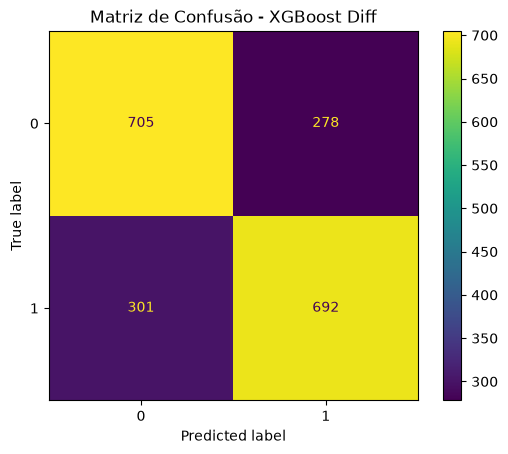

In [72]:
ConfusionMatrixDisplay.from_predictions(
    y_test_diff,
    y_pred_diff
)

plt.title('Matriz de Confusão - XGBoost Diff')
plt.show()

In [73]:
prob_blue_diff = melhor_xgb_diff.predict_proba(X_test_diff)[:, 1]

In [74]:
erros = y_test_diff != y_pred_diff

analise_erros = pd.DataFrame({
    'real': y_test_diff,
    'previsto': y_pred_diff,
    'prob_blue': prob_blue_diff
})

analise_erros_diff = analise_erros[erros]

In [75]:
erros_alta_confianca_diff = analise_erros_diff[
    (analise_erros_diff['prob_blue'] > 0.70) |
    (analise_erros_diff['prob_blue'] < 0.30)
]

for _, linha in erros_alta_confianca_diff.head(2).iterrows():

    if linha['real'] == 1 and linha['previsto'] == 0:
        print(
            f"ERRO: Blue venceu, mas o modelo previu derrota. "
            f"Probabilidade de vitória: {linha['prob_blue']:.2%}"
        )

    elif linha['real'] == 0 and linha['previsto'] == 1:
        print(
            f"ERRO: Blue perdeu, mas o modelo previu vitória. "
            f"Probabilidade de vitória: {linha['prob_blue']:.2%}"
        )

ERRO: Blue perdeu, mas o modelo previu vitória. Probabilidade de vitória: 76.82%
ERRO: Blue venceu, mas o modelo previu derrota. Probabilidade de vitória: 11.47%


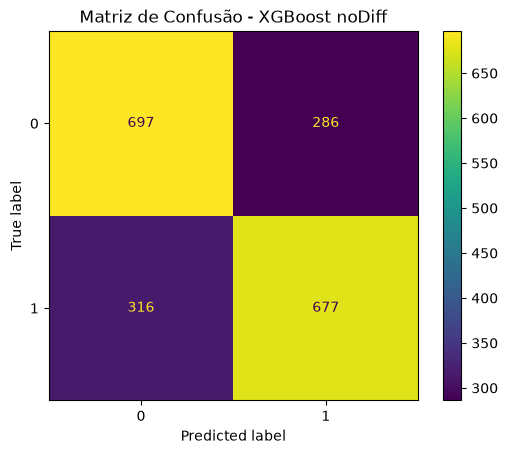

In [76]:
ConfusionMatrixDisplay.from_predictions(
    y_test_no_diff,
    y_pred_no_diff
)

plt.title('Matriz de Confusão - XGBoost noDiff')
plt.show()

In [77]:
prob_blue_no_diff = melhor_xgb_no_diff.predict_proba(X_test_no_diff)[:, 1]

In [78]:
erros = y_test_no_diff != y_pred_no_diff

analise_erros = pd.DataFrame({
    'real': y_test_no_diff,
    'previsto': y_pred_no_diff,
    'prob_blue': prob_blue_no_diff
})

analise_erros_no_diff = analise_erros[erros]

In [79]:
erros_alta_confianca_no_diff = analise_erros_no_diff[
    (analise_erros_no_diff['prob_blue'] > 0.70) |
    (analise_erros_no_diff['prob_blue'] < 0.30)
]

for _, linha in erros_alta_confianca_no_diff.head(2).iterrows():

    if linha['real'] == 1 and linha['previsto'] == 0:
        print(
            f"ERRO: Blue venceu, mas o modelo previu derrota. "
            f"Probabilidade de vitória: {linha['prob_blue']:.2%}"
        )

    elif linha['real'] == 0 and linha['previsto'] == 1:
        print(
            f"ERRO: Blue perdeu, mas o modelo previu vitória. "
            f"Probabilidade de vitória: {linha['prob_blue']:.2%}"
        )

ERRO: Blue perdeu, mas o modelo previu vitória. Probabilidade de vitória: 79.10%
ERRO: Blue venceu, mas o modelo previu derrota. Probabilidade de vitória: 74.99%


Para aprofundar a avaliação dos modelos, foram analisadas as **matrizes de confusão** do XGBoost nas representações `Diff` e `No Diff`. Essa análise permite identificar como os modelos distribuíram seus acertos e erros entre as classes.

#### 🔹 XGBoost — `Diff`

O modelo apresentou:

* **705 verdadeiros negativos (TN)**
* **278 falsos positivos (FP)**
* **301 falsos negativos (FN)**
* **692 verdadeiros positivos (TP)**

O modelo apresentou uma distribuição relativamente equilibrada entre os erros das duas classes. Houve **278 falsos positivos** e **301 falsos negativos**, indicando uma pequena tendência a errar mais ao prever a vitória do Blue quando o resultado real era uma derrota.

#### 🔹 XGBoost — `No Diff`

Para a representação `No Diff`, foram observados:

* **697 verdadeiros negativos (TN)**
* **286 falsos positivos (FP)**
* **316 falsos negativos (FN)**
* **677 verdadeiros positivos (TP)**

Assim como no `Diff`, os erros permaneceram relativamente equilibrados. Entretanto, o modelo apresentou mais erros em ambas as categorias quando comparado ao `Diff`.

#### 📊 Comparação

| Representação |      TN |      FP |      FN |      TP |
| ------------- | ------: | ------: | ------: | ------: |
| **Diff**      | **705** | **278** | **301** | **692** |
| No Diff       |     697 |     286 |     316 |     677 |

A representação **`Diff` apresentou um resultado ligeiramente superior**, com mais previsões corretas nas duas classes e menos erros em comparação ao `No Diff`.

Esse comportamento é consistente com os resultados observados anteriormente nas métricas de avaliação e na curva ROC, reforçando a indicação de que a representação baseada nas **diferenças entre as equipes** apresenta uma pequena vantagem para o XGBoost neste conjunto de dados.


### 📊 Análise da Importância das Features

In [80]:
modelo_xgb_diff = grid_xgb_diff.best_estimator_

importances_diff = modelo_xgb_diff.named_steps['modelo'].feature_importances_

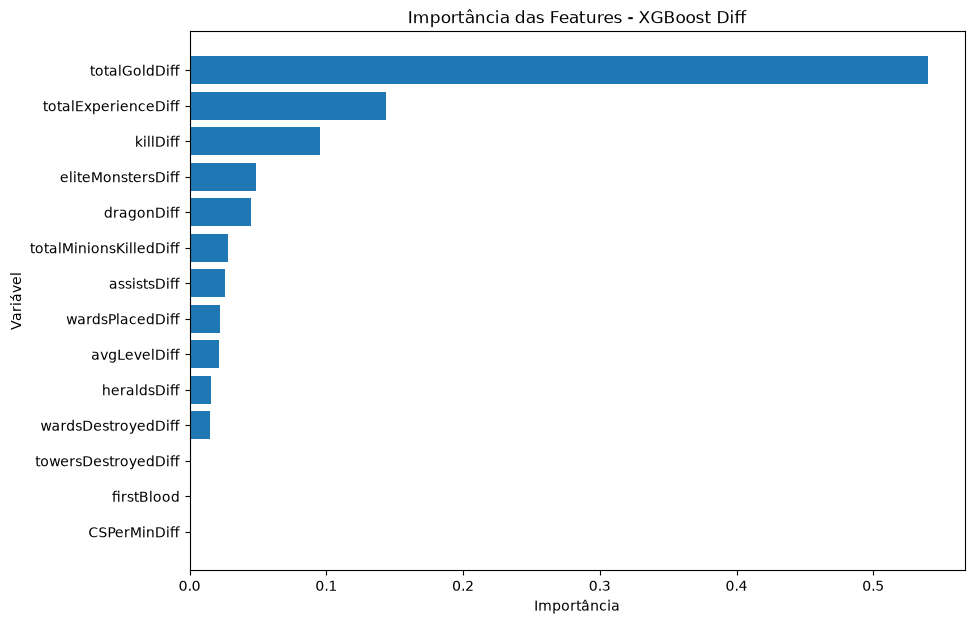

In [81]:
df_importance = pd.DataFrame({
    'feature': X_train_diff.columns,
    'importance': importances_diff
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    df_importance['feature'],
    df_importance['importance']
)

plt.xlabel('Importância')
plt.ylabel('Variável')
plt.title('Importância das Features - XGBoost Diff')

plt.show()

In [82]:
modelo_xgb_no_diff = grid_xgb_no_diff.best_estimator_

importances_no_diff = modelo_xgb_no_diff.named_steps['modelo'].feature_importances_

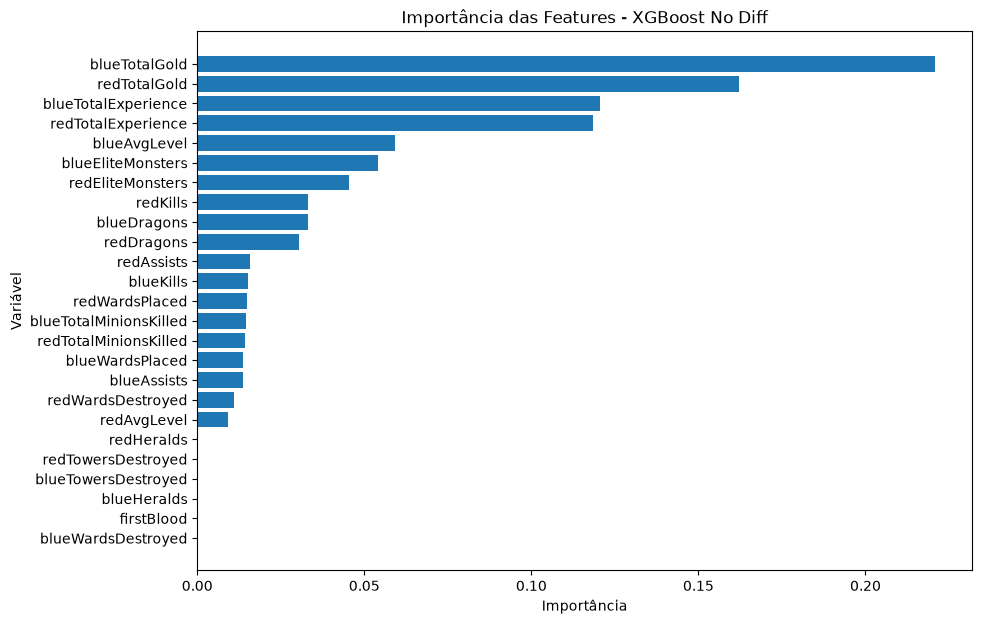

In [83]:
df_importance = pd.DataFrame({
    'feature': X_train_no_diff.columns,
    'importance': importances_no_diff
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    df_importance['feature'],
    df_importance['importance']
)

plt.xlabel('Importância')
plt.ylabel('Variável')
plt.title('Importância das Features - XGBoost No Diff')

plt.show()

Para complementar a avaliação do XGBoost, foi analisada a **importância das features** utilizadas pelos modelos `Diff` e `No Diff`. Essa análise permite identificar quais variáveis tiveram maior contribuição para as decisões realizadas pelo modelo.

#### 🔹 XGBoost — `Diff`

No modelo baseado nas diferenças entre as equipes, as variáveis que mais se destacaram foram:

* **`totalGoldDiff`** — apresentou a maior importância;
* **`totalExperienceDiff`** — segunda variável mais relevante;
* **`killDiff`** — também apresentou uma contribuição significativa;
* **`eliteMonstersDiff`** e **`dragonDiff`** — tiveram importância intermediária.

As demais variáveis apresentaram contribuições menores, enquanto `firstBlood`, `towersDestroyedDiff` e `CSPerMinDiff` tiveram pouca ou nenhuma importância no modelo.

#### 🔹 XGBoost — `No Diff`

Na representação com as informações das equipes separadas, **`blueTotalGold`** foi a variável mais importante, seguida por:

* `redTotalGold`;
* `blueTotalExperience`;
* `redTotalExperience`;
* `blueAvgLevel`;
* `blueEliteMonsters`.

Nesse formato, é possível observar que as informações relacionadas a **ouro e experiência** continuam predominando entre as características mais relevantes, mesmo quando as variáveis não são transformadas em diferenças.

#### 🔎 Comparação

Os dois modelos apresentam um padrão semelhante: **ouro e experiência possuem grande importância para a previsão do resultado da partida**.

A principal diferença está na forma como essas informações são utilizadas. No `Diff`, a vantagem de uma equipe sobre a outra é representada diretamente, fazendo com que `totalGoldDiff` e `totalExperienceDiff` apareçam entre as variáveis mais importantes. Já no `No Diff`, o modelo precisa analisar separadamente os valores de Blue e Red, resultando em `blueTotalGold`, `redTotalGold`, `blueTotalExperience` e `redTotalExperience` entre as principais features.

Essa análise reforça a utilidade da engenharia de atributos realizada no projeto e ajuda a interpretar quais características das partidas são mais relevantes para a previsão de `blueWins`.

> **Observação:** a importância das features indica a contribuição delas para as decisões do modelo, mas **não significa causalidade**. Portanto, uma variável mais importante não necessariamente é a causa de uma vitória, apenas foi mais utilizada pelo modelo para realizar suas previsões.


In [104]:
prob_real_diff, prob_pred_diff = calibration_curve(
    y_test_diff,
    prob_blue_diff,
    n_bins=10
)

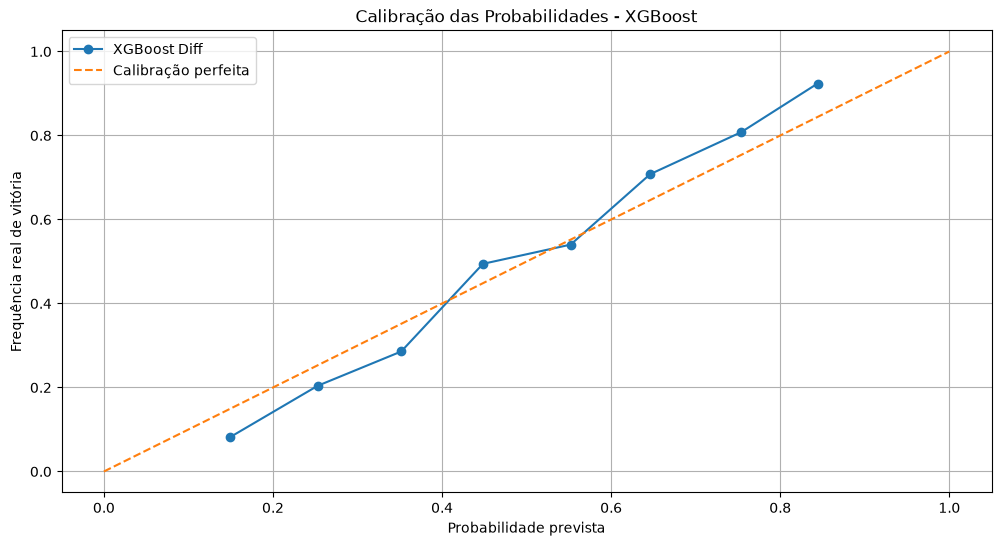

In [106]:
plt.figure(figsize=(12, 6))

plt.plot(
    prob_pred_diff,
    prob_real_diff,
    marker='o',
    label='XGBoost Diff'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Calibração perfeita'
)

plt.xlabel('Probabilidade prevista')
plt.ylabel('Frequência real de vitória')
plt.title('Calibração das Probabilidades - XGBoost')
plt.legend()
plt.grid()
plt.show()

#### 📈 Calibração das Probabilidades — XGBoost

A curva de calibração indica que as probabilidades previstas pelo XGBoost apresentam uma **calibração razoavelmente próxima da ideal**. Apesar de algumas diferenças em determinados intervalos, a maioria dos pontos permanece próxima da linha de calibração perfeita, indicando que as probabilidades estimadas são coerentes com a frequência real de vitórias.

## Erros - Random Forest

### 🔎 Análise das Matrizes de Confusão

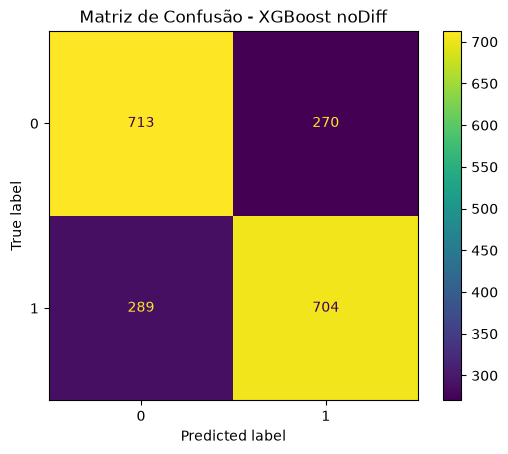

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_diff,
    RFy_pred_diff
)

plt.title('Matriz de Confusão - Random Forest Diff')
plt.show()

In [85]:
prob_blue_RFdiff = melhor_rf_diff.predict_proba(X_test_diff)[:, 1]

In [86]:
erros_rf = y_test_diff != RFy_pred_diff

analise_erros_rf = pd.DataFrame({
    'real': y_test_diff,
    'previsto': RFy_pred_diff,
    'prob_blue': prob_blue_RFdiff
})

analise_erros_RFdiff = analise_erros_rf[erros_rf]

In [87]:
erros_alta_confianca_RFdiff = analise_erros_RFdiff[
    (analise_erros_RFdiff['prob_blue'] > 0.70) |
    (analise_erros_RFdiff['prob_blue'] < 0.30)
]

for _, linha in erros_alta_confianca_RFdiff.head(2).iterrows():

    if linha['real'] == 1 and linha['previsto'] == 0:
        print(
            f"ERRO: Blue venceu, mas o modelo previu derrota. "
            f"Probabilidade de vitória: {linha['prob_blue']:.2%}"
        )

    elif linha['real'] == 0 and linha['previsto'] == 1:
        print(
            f"ERRO: Blue perdeu, mas o modelo previu vitória. "
            f"Probabilidade de vitória: {linha['prob_blue']:.2%}"
        )

ERRO: Blue perdeu, mas o modelo previu vitória. Probabilidade de vitória: 83.13%
ERRO: Blue venceu, mas o modelo previu derrota. Probabilidade de vitória: 25.04%


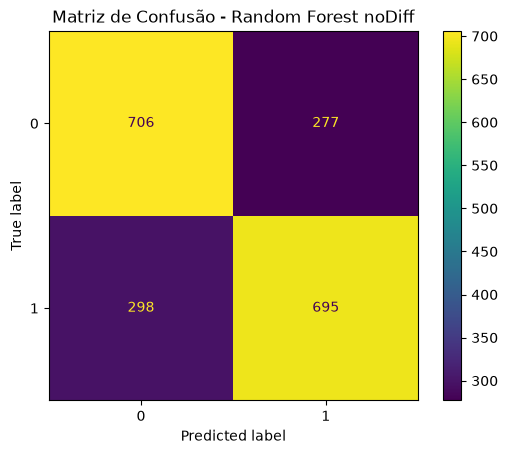

In [89]:
ConfusionMatrixDisplay.from_predictions(
    y_test_no_diff,
    RFy_pred_no_diff
)

plt.title('Matriz de Confusão - Random Forest noDiff')
plt.show()

In [93]:
prob_blue_RFnoDiff = melhor_rf_no_diff.predict_proba(X_test_no_diff)[:, 1]

In [94]:
erros_RFnoDiff = y_test_diff != RFy_pred_no_diff

analise_erros_RFnoDiff = pd.DataFrame({
    'real': y_test_diff,
    'previsto': RFy_pred_no_diff,
    'prob_blue': prob_blue_RFnoDiff
})

analise_erros_RFnoDiff = analise_erros_RFnoDiff[erros_RFnoDiff]

In [95]:
erros_alta_confianca_RFnoDiff = analise_erros_RFnoDiff[
    (analise_erros_RFnoDiff['prob_blue'] > 0.70) |
    (analise_erros_RFnoDiff['prob_blue'] < 0.30)
]

for _, linha in erros_alta_confianca_RFnoDiff.head(2).iterrows():

    if linha['real'] == 1 and linha['previsto'] == 0:
        print(
            f"ERRO: Blue venceu, mas o modelo previu derrota. "
            f"Probabilidade de vitória: {linha['prob_blue']:.2%}"
        )

    elif linha['real'] == 0 and linha['previsto'] == 1:
        print(
            f"ERRO: Blue perdeu, mas o modelo previu vitória. "
            f"Probabilidade de vitória: {linha['prob_blue']:.2%}"
        )

ERRO: Blue perdeu, mas o modelo previu vitória. Probabilidade de vitória: 77.13%
ERRO: Blue venceu, mas o modelo previu derrota. Probabilidade de vitória: 26.08%


#### 🔹 Random Forest — `Diff`

O modelo apresentou:

- **706 verdadeiros negativos (TN)**
- **277 falsos positivos (FP)**
- **298 falsos negativos (FN)**
- **695 verdadeiros positivos (TP)**

#### 🔹 Random Forest — `No Diff`

O modelo apresentou:

- **706 verdadeiros negativos (TN)**
- **277 falsos positivos (FP)**
- **298 falsos negativos (FN)**
- **695 verdadeiros positivos (TP)**

#### 📊 Comparação

| Representação | TN | FP | FN | TP |
|---|---:|---:|---:|---:|
| **Diff** | 706 | 277 | 298 | 695 |
| **No Diff** | 706 | 277 | 298 | 695 |

Os dois modelos apresentaram **exatamente a mesma distribuição de acertos e erros** no conjunto de teste. Dessa forma, a representação `Diff` não apresentou vantagem sobre `No Diff` nessa análise específica do Random Forest.

Além disso, os erros permaneceram relativamente equilibrados entre as classes, indicando que o modelo não apresenta uma tendência significativa de favorecer uma das classes.

### 📊 Análise da Importância das Features

In [96]:
modelo_rf_diff = grid_rf_diff.best_estimator_

importances_diff = modelo_rf_diff.named_steps['modelo'].feature_importances_

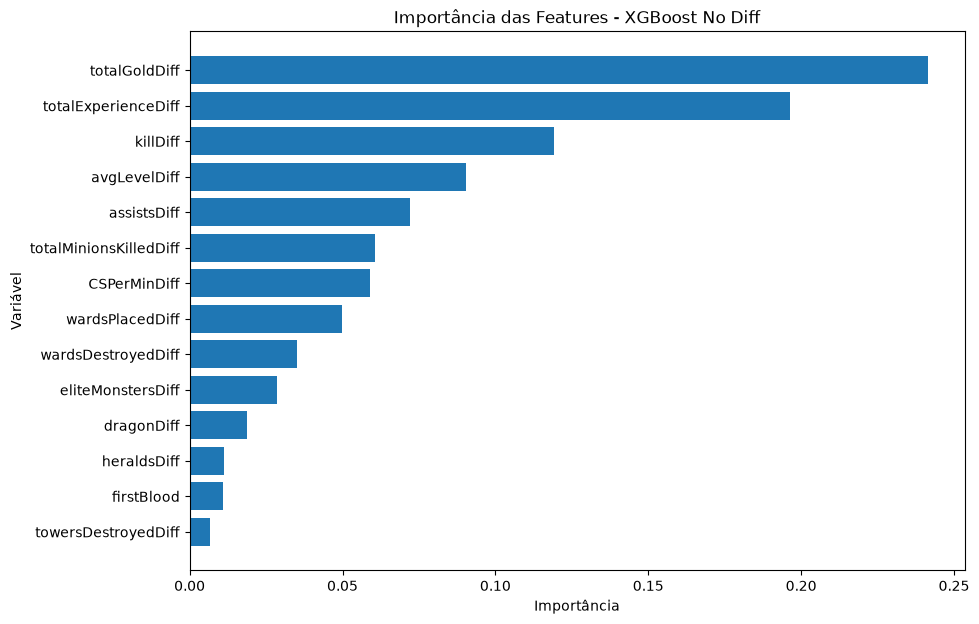

In [ ]:
df_importance_diff = pd.DataFrame({
    'feature': X_train_diff.columns,
    'importance': importances_diff
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    df_importance_diff['feature'],
    df_importance_diff['importance']
)

plt.xlabel('Importância')
plt.ylabel('Variável')
plt.title('Importância das Features - Random Forest Diff')

plt.show()

In [100]:
modelo_rf_no_diff = grid_rf_no_diff.best_estimator_

importances_no_diff = modelo_rf_no_diff.named_steps['modelo'].feature_importances_

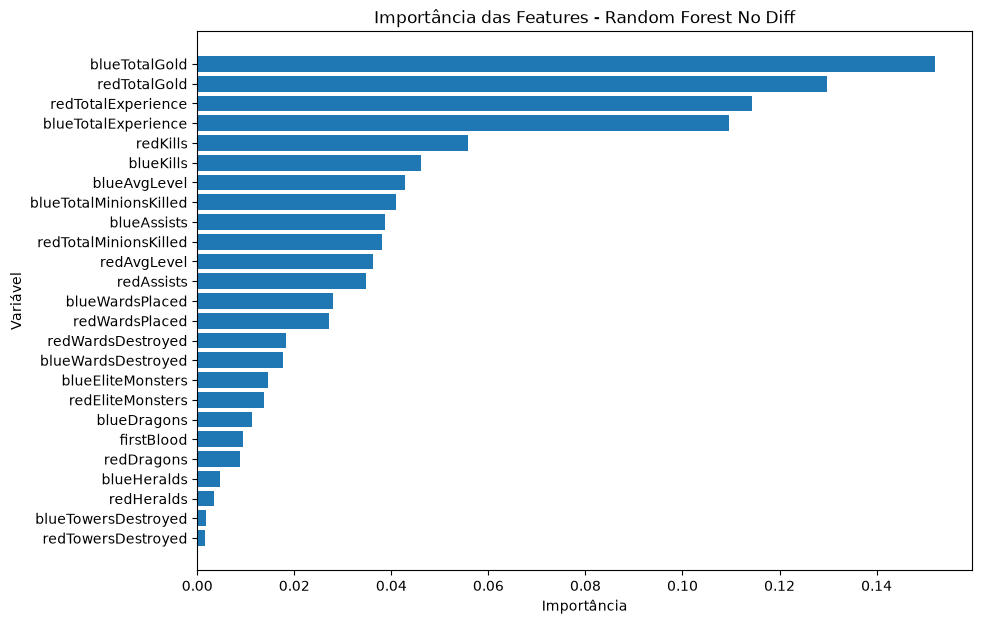

In [101]:
df_importance_no_diff = pd.DataFrame({
    'feature': X_train_no_diff.columns,
    'importance': importances_no_diff
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    df_importance_no_diff['feature'],
    df_importance_no_diff['importance']
)

plt.xlabel('Importância')
plt.ylabel('Variável')
plt.title('Importância das Features - Random Forest No Diff')

plt.show()

#### 🔹 Random Forest — `Diff`

As variáveis que apresentaram maior importância foram:

1. `totalGoldDiff`
2. `totalExperienceDiff`
3. `killDiff`
4. `avgLevelDiff`
5. `assistsDiff`
6. `totalMinionsKilledDiff`

Observa-se uma predominância de variáveis relacionadas a **ouro, experiência e desempenho das equipes**, indicando que essas características tiveram maior participação nas decisões do modelo.

#### 🔹 Random Forest — `No Diff`

No modelo `No Diff`, as principais variáveis foram:

1. `blueTotalGold`
2. `redTotalGold`
3. `redTotalExperience`
4. `blueTotalExperience`
5. `redKills`
6. `blueKills`

Nesse formato, as informações de ouro e experiência continuam entre as características mais relevantes, porém são representadas separadamente para cada equipe.

#### 🔎 Comparação

Os dois formatos apresentam padrões semelhantes quanto às características mais relevantes. No `Diff`, as vantagens entre as equipes são representadas diretamente, fazendo com que variáveis como `totalGoldDiff`, `totalExperienceDiff` e `killDiff` apresentem maior destaque.

Já no `No Diff`, o modelo precisa analisar separadamente as informações das equipes Blue e Red, fazendo com que variáveis como `blueTotalGold`, `redTotalGold`, `blueTotalExperience` e `redTotalExperience` apareçam individualmente entre as mais importantes.

Os resultados também são consistentes com a análise realizada no XGBoost, reforçando que **ouro, experiência e desempenho em combate estão entre as características mais relevantes para a previsão de `blueWins`**.

> **Observação:** a importância das features representa a contribuição das variáveis para as decisões do modelo, mas não indica causalidade. Uma variável mais importante não necessariamente é a causa de uma vitória.

In [108]:
prob_real_noDiff, prob_pred_noDiff = calibration_curve(
    y_test_no_diff,
    prob_blue_no_diff,
    n_bins=10
)

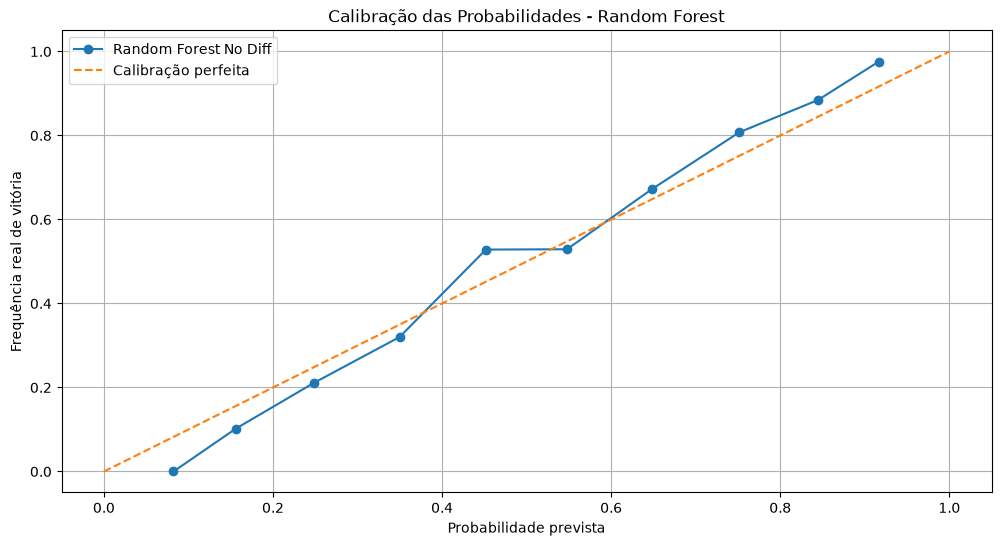

In [109]:
plt.figure(figsize=(12, 6))

plt.plot(
    prob_pred_noDiff,
    prob_real_noDiff,
    marker='o',
    label='Random Forest No Diff'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Calibração perfeita'
)

plt.xlabel('Probabilidade prevista')
plt.ylabel('Frequência real de vitória')
plt.title('Calibração das Probabilidades - Random Forest')
plt.legend()
plt.grid()
plt.show()

#### 📈 Calibração das Probabilidades — Random Forest

A curva de calibração do Random Forest também apresenta comportamento próximo da linha de calibração perfeita. O modelo demonstra uma **boa correspondência entre as probabilidades previstas e a frequência real de vitórias**, embora apresente algumas diferenças nos extremos e em determinadas faixas de probabilidade.

# 9. 🏁 Conclusão

Ao longo do projeto, foram analisados dados de partidas de **League of Legends** com o objetivo de desenvolver modelos capazes de prever a vitória da equipe Blue (`blueWins`).

Durante o processo, foram avaliadas duas formas de representação dos dados: `lol_diff`, utilizando diferenças entre as equipes, e `lol_no_diff`, mantendo as informações de cada equipe separadamente. Também foram removidas variáveis redundantes e informações que representavam essencialmente o mesmo atributo.

Foram utilizados os modelos **XGBoost** e **Random Forest**, avaliados inicialmente em suas configurações base e posteriormente otimizados utilizando **GridSearchCV com validação cruzada de 5 folds**. A avaliação considerou métricas como Accuracy, Precision, Recall, F1-score e ROC-AUC, além das matrizes de confusão, análise dos erros, calibração das probabilidades e importância das features.

## 📊 Principais resultados

Os resultados demonstraram um desempenho bastante semelhante entre Random Forest e XGBoost. Na análise da curva ROC, os melhores resultados foram obtidos com a representação `Diff`:

- **XGBoost `Diff`: AUC = 0,815**
- **Random Forest `Diff`: AUC = 0,814**

Para `No Diff`, ambos apresentaram **AUC = 0,810**.

A pequena diferença entre os modelos indica que, neste conjunto de dados, **não houve uma vantagem significativa de um algoritmo sobre o outro**. Entretanto, a representação baseada em diferenças apresentou uma pequena vantagem para os dois modelos.

## 🔎 Principais características

A análise da importância das features mostrou que variáveis relacionadas a **ouro, experiência e desempenho das equipes** tiveram maior relevância para as previsões.

Na representação `Diff`, `totalGoldDiff`, `totalExperienceDiff` e `killDiff` estiveram entre as características mais importantes. No formato `No Diff`, variáveis como `blueTotalGold`, `redTotalGold`, `blueTotalExperience` e `redTotalExperience` também apresentaram grande relevância.

Esse comportamento indica que a vantagem acumulada entre as equipes ao longo da partida possui forte relação com o resultado final.

## 🎯 Conclusão final

Com base nos resultados obtidos, o **XGBoost otimizado utilizando a representação `Diff`** foi escolhido como o modelo de melhor desempenho, apresentando **AUC de 0,815** e resultados equilibrados entre as classes.

Apesar disso, a diferença em relação ao Random Forest foi mínima, mostrando que ambos os modelos foram capazes de aprender padrões relevantes nos dados.

Por fim, os resultados demonstram que a engenharia de atributos baseada nas **diferenças entre as equipes** foi uma abordagem eficiente para representar os dados e auxiliar na previsão de `blueWins`. O projeto também evidencia que características como vantagem em ouro, experiência e eliminações possuem grande importância na identificação do possível vencedor de uma partida.